#  **QUẢN TRỊ NHÂN SỰ VÀ VẬN HÀNH 2022-2024**

### **Mục tiêu:**
Phân tích tình hình lực lượng lao động cũng như tình hình kinh doanh trong 3 năm 2022 - 2024 để đưa ra các thông tin chi tiết hỗ trợ cải thiện sự gắn kết, tối ưu hóa hiệu suất và nâng cao hiệu quả doanh nghiệp.


### **Sơ lược về dữ liệu:**
Tập dữ liệu mô phỏng một hệ thống quản lý nhân sự chuyên nghiệp với các thông tin:
- Nhân khẩu học: Độ tuổi, trình độ học vấn, vai trò công việc, cấp bậc.
- Hiệu suất: Điểm đánh giá, giờ đào tạo, làm thêm giờ (overtime), tỷ lệ vắng mặt, chỉ số gắn kết.
- Tài chính: Lương, thưởng, chi phí phúc lợi.
- Quản trị: Mối quan hệ với quản lý, thăng tiến, lộ trình sự nghiệp.
- Vận hành: Địa điểm cửa hàng, phòng ban, loại hình công việc, kết quả kinh doanh.
- KPIs: Chỉ số năng suất, điểm hài lòng của khách hàng theo từng vai trò.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Phần 1: Khởi tạo và tải dữ liệu**

In [ ]:
# 1. Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Thiết lập phong cách biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.facecolor'] = '#f5f2ee'

In [ ]:
data_file = "/content/drive/MyDrive/1. Project-Based/Final Project/Employee Performance Dataset.xlsx"

# Load all sheets
print('Loading HR data...')
df_employees = pd.read_excel(data_file, sheet_name='employees')
df_monthly_performance = pd.read_excel(data_file, sheet_name='monthly_performance')
df_role_kpis = pd.read_excel(data_file, sheet_name='role_kpis')
df_business_outcomes = pd.read_excel(data_file, sheet_name='business_outcomes')
df_stores = pd.read_excel(data_file, sheet_name='stores')

# Convert 'Year_Month' to datetime here,
df_monthly_performance['Year_Month'] = pd.to_datetime(df_monthly_performance['Year_Month'])
df_role_kpis['Year_Month'] = pd.to_datetime(df_role_kpis['Year_Month'])
df_business_outcomes['Year_Month'] = pd.to_datetime(df_business_outcomes['Year_Month'])

print(f'Employees: {df_employees.shape}')
print(f'Monthly Performance: {df_monthly_performance.shape}')
print(f'KPIs: {df_role_kpis.shape}')
print(f'Business Outcomes: {df_business_outcomes.shape}')
print(f'Stores: {df_stores.shape}')

Loading HR data...
Employees: (7500, 18)
Monthly Performance: (236591, 13)
KPIs: (236591, 9)
Business Outcomes: (16200, 9)
Stores: (150, 7)


# **Phần 2: Tiền xử lý dữ liệu & Thống kê sơ bộ**

In [ ]:
def check_dataframe(df):

    print("\n--- Head of DataFrame ---")
    print(df.head(2))

    print("\n--- DataFrame Info ---")
    df.info()

    #print("\n--- Descriptive Statistics ---")
    #print(df.describe(include='all'))

    print("\n--- Missing Values ---")
    missing_values = df.isnull().sum()
    missing_values = missing_values[missing_values > 0]
    if not missing_values.empty:
        print(missing_values.sort_values(ascending=False))
    else:
        print("No missing values found.")

    print(f"\n Số dòng trùng lặp: {df.duplicated().sum()}")

# Example usage:
# check_dataframe(df)

In [ ]:
check_dataframe(df_employees)

In [ ]:
check_dataframe(df_stores)

In [ ]:
check_dataframe(df_monthly_performance)

In [ ]:
check_dataframe(df_role_kpis)

In [ ]:
check_dataframe(df_business_outcomes)

In [ ]:
df_employees['Hire_Date'] = pd.to_datetime(df_employees['Hire_Date'], dayfirst=True)
df_employees['Exit_Date'] = pd.to_datetime(df_employees['Exit_Date'], dayfirst=True)


In [ ]:
max_date = pd.to_datetime('2024-12-31')

# Calculate Tenure_Months for df_employees
df_employees['Tenure_End_Date'] = df_employees['Exit_Date'].fillna(max_date)

df_employees['Tenure_Months'] = (
    df_employees['Tenure_End_Date'].dt.to_period('M') -
    df_employees['Hire_Date'].dt.to_period('M')
).apply(lambda x: x.n)

# Drop the temporary Tenure_End_Date column
df_employees.drop(columns=['Tenure_End_Date'], inplace=True)

print("Cột 'Tenure_Months' đã được thêm vào df_employees.")
print(df_employees[['Employee_Id', 'Hire_Date', 'Exit_Date', 'Tenure_Months']].head())

Cột 'Tenure_Months' đã được thêm vào df_employees.
  Employee_Id  Hire_Date  Exit_Date  Tenure_Months
0   EMP000001 2021-04-26 2022-04-13             12
1   EMP000002 2021-09-03        NaT             39
2   EMP000003 2016-08-25        NaT            100
3   EMP000004 2021-12-10        NaT             36
4   EMP000005 2018-02-24        NaT             82


In [ ]:
# df: Used for general analysis, filtered to exclude employees who exited before 2022.
# df_em: Used for comprehensive employee career summaries, includes all employees for attrition analysis.

# Filter df_employees to create 'df' (main analysis dataframe)
df_2024 = df_employees[~(df_employees['Exit_Date'] < pd.to_datetime('2022-01-01'))].copy() # .copy() to avoid SettingWithCopyWarning
df = df_2024.merge(df_monthly_performance, on='Employee_Id', how='left')
df = df.merge(df_role_kpis, on=['Employee_Id','Year_Month'], how='left')

# Create 'df_em' (employee master for full career history)
df_em = df_employees.merge(df_monthly_performance, on='Employee_Id', how='left')
df_em = df_em.merge(df_role_kpis, on=['Employee_Id','Year_Month'], how='left')

# df_stores: Merge with business outcomes (already converted Year_Month above)
df_stores = df_stores.merge(df_business_outcomes, on='Store_Id', how='left')

# **Phần 3: Phân tích cơ bản**



In [ ]:
# Tính toán các chỉ số cơ bản:
total_employees = df_2024['Employee_Id'].nunique()
print(f"Tổng số nhân viên 2022-2024: {total_employees}")

Tổng số nhân viên 2022-2024: 7086


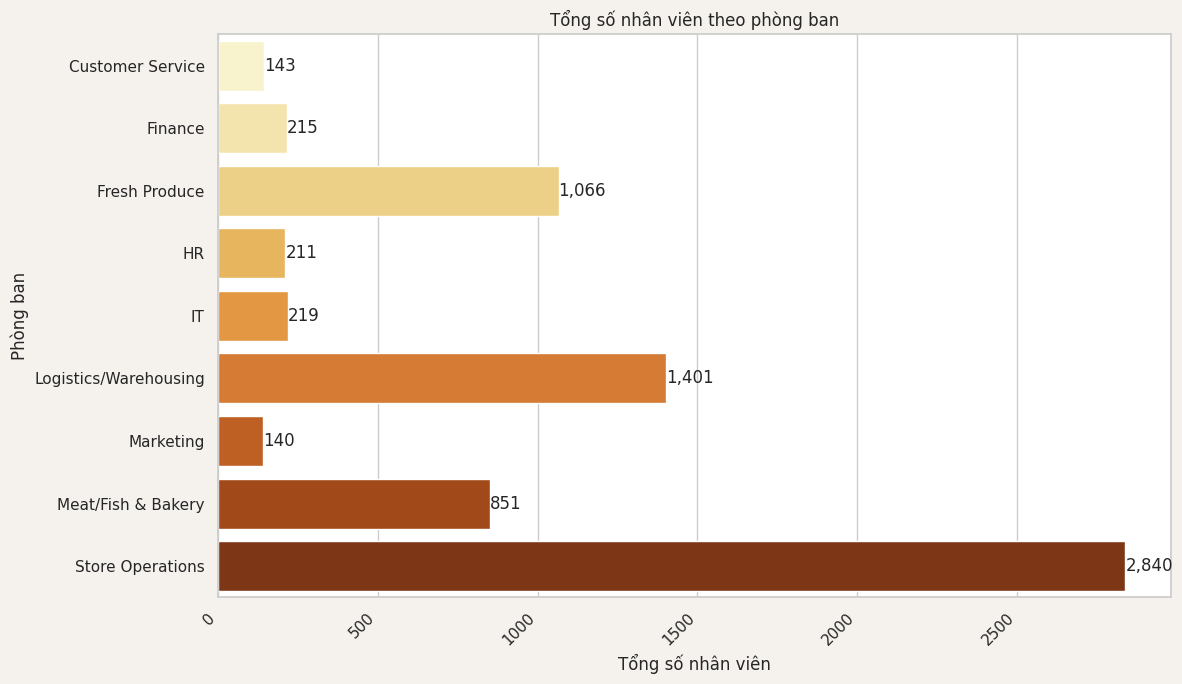

In [ ]:
employees_by_department = df_2024.groupby('Department')['Employee_Id'].nunique().reset_index()
employees_by_department.columns = ['Department', 'Total Employees']

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Total Employees', y='Department', data=employees_by_department, palette='YlOrBr', hue ='Department', legend=False)
plt.title('Tổng số nhân viên theo phòng ban')
plt.xlabel('Tổng số nhân viên')
plt.ylabel('Phòng ban')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

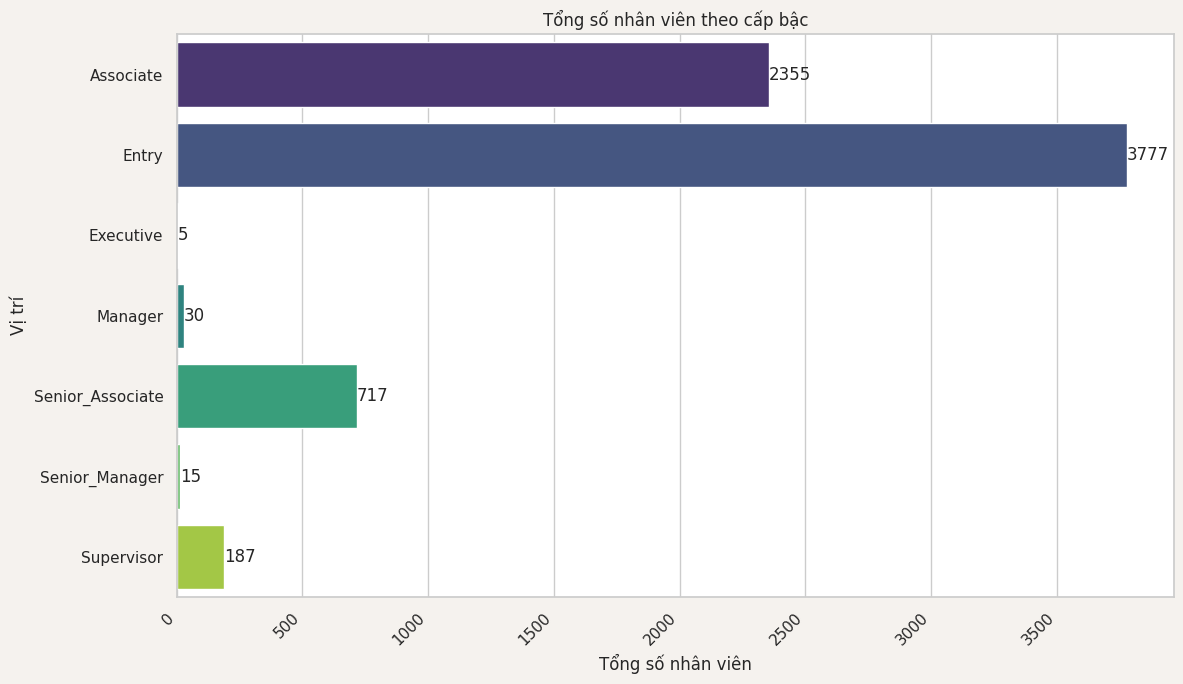

In [ ]:
employees_by_department = df_2024.groupby('Job_Level')['Employee_Id'].nunique().reset_index()
employees_by_department.columns = ['Job_Level', 'Total Employees']

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Total Employees', y='Job_Level', data=employees_by_department, palette='viridis', hue ='Job_Level', legend=False)
plt.title('Tổng số nhân viên theo cấp bậc')
plt.xlabel('Tổng số nhân viên')
plt.ylabel('Vị trí')
plt.xticks(rotation=45, ha='right')

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

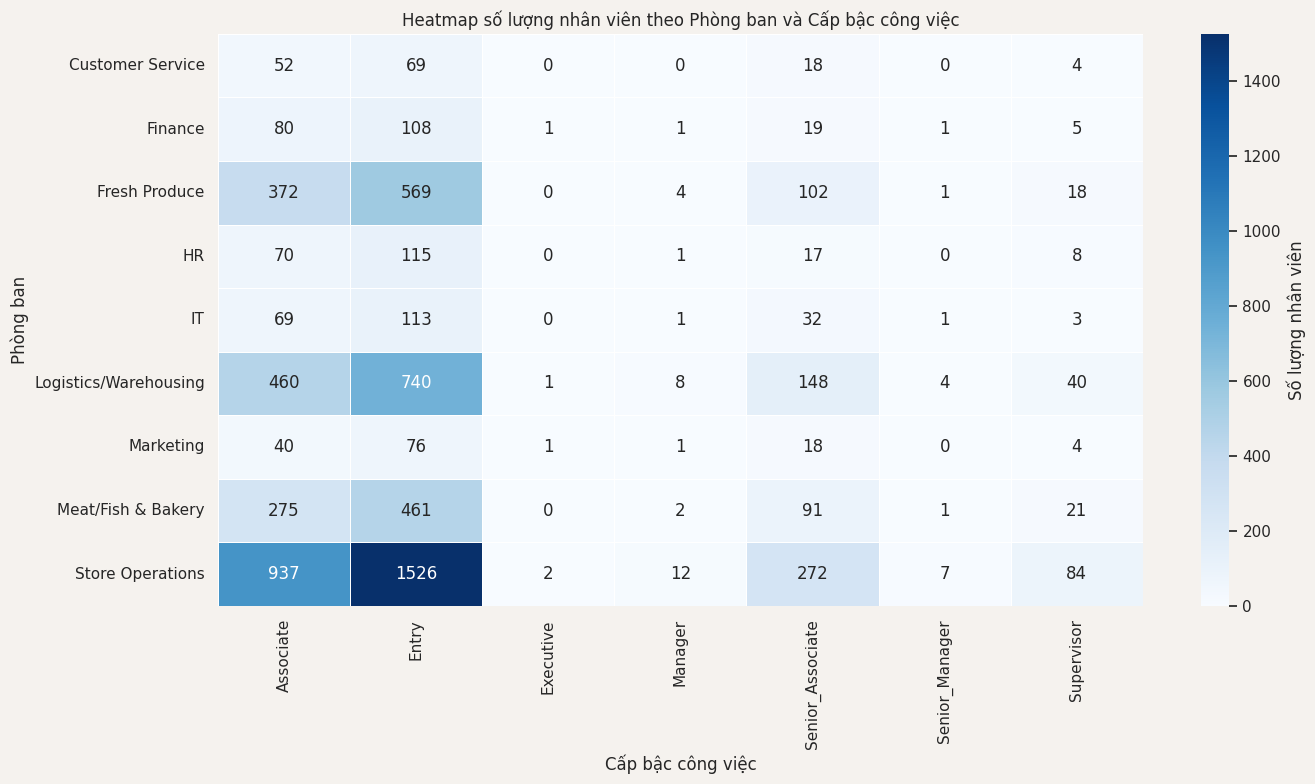

In [ ]:
# Calculate total employee count for each combination of Department and Job_Level
employee_count_by_dep_job = df_2024.groupby(['Department', 'Job_Level'])['Employee_Id'].nunique().reset_index()
employee_count_by_dep_job.columns = ['Department', 'Job_Level', 'Employee_Count']

# Create a pivot table for the heatmap
heatmap_data_employee_count = employee_count_by_dep_job.pivot_table(
    index='Department',
    columns='Job_Level',
    values='Employee_Count'
).fillna(0) # Fill NaN with 0 for combinations with no employees

# Plotting the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data_employee_count, annot=True, fmt="g", cmap="Blues", linewidths=.5, cbar_kws={'label': 'Số lượng nhân viên'})
plt.title('Heatmap số lượng nhân viên theo Phòng ban và Cấp bậc công việc')
plt.xlabel('Cấp bậc công việc')
plt.ylabel('Phòng ban')
plt.tight_layout()
plt.show()

In [ ]:
# Thống kê tóm tắt cho cột Age và Base_Salary_Annual
print("Thống kê tóm tắt cho cột Age và Base_Salary_Annual:")
df_2024[['Age', 'Base_Salary_Annual', 'Tenure_Months']].describe()

Thống kê tóm tắt cho cột Age và Base_Salary_Annual:


,Age,Base_Salary_Annual,Tenure_Months
count,7086.000000,7086.000000,7086.000000
mean,32.335732,27466.456974,58.012560
std,7.451905,10176.182819,26.474008
min,21.000000,8823.460000,3.000000
25%,26.250000,21057.812500,41.000000
50%,32.000000,27575.600000,51.000000
75%,37.000000,32035.062500,69.000000
max,64.000000,177873.610000,155.000000


**TỔNG QUAN:**
- Tổng số lượng nhân viên là 7086 người với Store Operations lên đến 2850 nhân viên, tiếp theo là Logistics/Warehousing là ~1400 và Fresh Produce là 1066 người. Bộ phận Marketing và Customer Service có số lượng nhân viên thấp nhất là ~ 140 người/phòng ban.
- Độ tuổi trung bình là 32 tuổi với người nhỏ tuổi nhất là 21 tuổi trong khi người lớn nhất là 64 tuổi. 75% nhân viên ở độ tuổi dưới 37 tuổi. Chỉ một con số rất nhỏ nhân viên có độ tuổi trên 50.
- Thâm niên trung bình 58 tháng ~ 5 năm, đa phần nhân sự gắn bó từ trên 3 năm ~ 6 năm cho thấy lực lượng lao động đều làm việc lâu dài và tâm huyết với công ty.


**CHẾ ĐỘ LƯƠNG**
- Tổng quan về lương:
    - Mức lương trung bình ở mức ~ $27,253/ năm
    
    - Mức cao nhất lên tới $177,873/ năm
    
    - Mức lương tối thiểu chưa được $9,000/năm

    - 75 % nhân viên ở mức dưới $32,000/năm.
  
Số lượng người có mức lương vượt ngoài mức chung của công ty không quá nhiều nhưng mức lương của những người này cao hơn rất nhiều số đông còn lại. Đây là 1 điểm cần chú ý để phân tích về sau.

# **Phần 4. Kết quả kinh doanh**

## 4.1 Tổng quan doanh thu

In [ ]:


df_stores['Month'] = df_stores['Year_Month'].dt.month
df_stores['Year'] = df_stores['Year_Month'].dt.year

df_stores_by_year = df_stores.groupby(['Year'])['Sales_Actual'].sum().reset_index()
df_stores_by_year.rename(columns={'Sales_Actual': 'Total_Sales_Actual'}, inplace=True)
df_stores_by_year['Total_Sales_Million'] = (df_stores_by_year['Total_Sales_Actual'] / 1e6).round()
print("Tổng doanh thu theo năm:")
display(df_stores_by_year.sort_values(by='Year'))

# Calculate total sales by month and year
total_sales_by_month_year = df_stores.groupby(['Year', 'Month'])['Sales_Actual'].sum().reset_index()

# Create a line plot with Plotly Express
fig = px.line(total_sales_by_month_year,
              x='Month',
              y='Sales_Actual',
              color='Year',
              title='Tổng doanh thu theo tháng và năm',
              labels={'Sales_Actual': 'Tổng doanh thu', 'Month': 'Tháng', 'Year': 'Năm'},
              line_group='Year',
              hover_name='Year')

fig.update_layout(
    xaxis = dict(
        tickmode = 'array',
        tickvals = list(range(1, 13)),
        ticktext = ['Tháng 1', 'Tháng 2', 'Tháng 3', 'Tháng 4', 'Tháng 5', 'Tháng 6', 'Tháng 7', 'Tháng 8', 'Tháng 9', 'Tháng 10', 'Tháng 11', 'Tháng 12']
    )
)

fig.show()

Tổng doanh thu theo năm:


,Year,Total_Sales_Actual,Total_Sales_Million
0,2022,6.582092e+08,658.0
1,2023,6.615439e+08,662.0
2,2024,6.597739e+08,660.0


INSIGHT:
- Doanh thu 3 năm 2022-2023-2024 lần lượt là 658tr - 662tr - 660tr và có tính chu kỳ.
- Có 150 cửa hàng, chia làm 3 loại hình SuperStore, Regular, Express. SuperStore với 51 điểm kinh doanh luôn đứng đầu về doanh thu chiếm ~ 50% tổng doanh thu, tiếp theo là loại hình Regular - loại hình chiếm số đông nhất với 80 điểm kinh doanh đạt ~ 44$ doanh thu và loại hình Express chỉ dao động quanh mức 6.5% tổng quanh thu với 19 cửa hàng.

## **4.2 Top 5 và Bottom 5 cửa hàng theo doanh thu**

In [ ]:

# Calculate total revenue (Sales_Actual) for each store per year
store_revenue_by_year = df_stores.groupby(['Year', 'Store_Id', 'Store_Name','City','Store_Type'])['Sales_Actual'].sum().reset_index()

# Rank stores by total revenue within each year
store_revenue_by_year['Rank'] = store_revenue_by_year.groupby('Year')['Sales_Actual'].rank(ascending=False, method='dense')

# Sort the results by Year and Rank
store_revenue_by_year = store_revenue_by_year.sort_values(by=['Year', 'Rank'])
store_revenue_by_year['Rank'] = store_revenue_by_year['Rank'].astype(int)
#store_revenue_by_year = store_revenue_by_year[store_revenue_by_year['Rank'==1]]

print("Xếp hạng cửa hàng theo tổng doanh thu hàng năm:")
display(store_revenue_by_year.sort_values(by=['Year','Rank']).head(10)) # Display top 20 entries to show ranking for multiple years

Xếp hạng cửa hàng theo tổng doanh thu hàng năm:


,Year,Store_Id,Store_Name,City,Store_Type,Sales_Actual,Rank
29,2022,STR030,Houston Superstore #30,Houston,Superstore,8221490.56,1
80,2022,STR081,New York Superstore #81,New York,Superstore,8120293.21,2
142,2022,STR143,New York Superstore #143,New York,Superstore,8072475.57,3
5,2022,STR006,Houston Superstore #6,Houston,Superstore,7923836.23,4
75,2022,STR076,New York Superstore #76,New York,Superstore,7885903.59,5
131,2022,STR132,Houston Superstore #132,Houston,Superstore,7883139.09,6
6,2022,STR007,Chicago Superstore #7,Chicago,Superstore,7787933.69,7
50,2022,STR051,Los Angeles Superstore #51,Los Angeles,Superstore,7641412.32,8
103,2022,STR104,Houston Superstore #104,Houston,Superstore,7569994.79,9
94,2022,STR095,Houston Superstore #95,Houston,Superstore,7385719.89,10


In [ ]:
import plotly.colors # Import plotly.colors

# Calculate total revenue for each store across all years, including Store_Type
total_revenue_by_store_and_type = store_revenue_by_year.groupby(['Store_Id', 'Store_Name', 'Store_Type'])['Sales_Actual'].sum().reset_index()

# Get overall top 5 stores (this is needed for downstream analysis)
overall_top_5 = total_revenue_by_store_and_type.nlargest(5, 'Sales_Actual')

# Get overall bottom 5 stores (this is needed for downstream analysis)
overall_bottom_5 = total_revenue_by_store_and_type.nsmallest(5, 'Sales_Actual')

# --- Start of new per-Store_Type analysis for visualization ---
all_selected_stores_for_plot = []

for store_type in total_revenue_by_store_and_type['Store_Type'].unique():
    df_type = total_revenue_by_store_and_type[total_revenue_by_store_and_type['Store_Type'] == store_type]

    # Get top 5 stores for the current type
    top_5_type = df_type.nlargest(5, 'Sales_Actual')
    # Get bottom 5 stores for the current type
    bottom_5_type = df_type.nsmallest(5, 'Sales_Actual')

    all_selected_stores_for_plot.append(top_5_type)
    all_selected_stores_for_plot.append(bottom_5_type)

# Combine all selected stores for plotting
combined_stores_for_plot = pd.concat(all_selected_stores_for_plot)

# Sort for better visualization within each facet
combined_stores_for_plot = combined_stores_for_plot.sort_values(by=['Store_Type', 'Sales_Actual'], ascending=[True, True])

fig = px.bar(combined_stores_for_plot, # Use the new DataFrame for plotting
             x='Store_Name',
             y='Sales_Actual',
             color='Sales_Actual',
             color_continuous_scale=plotly.colors.diverging.RdYlGn,
             facet_col='Store_Type', # Facet by Store_Type
             facet_col_wrap=2, # Wrap facets after 2 columns
             title='Tổng doanh thu của 5 cửa hàng hàng đầu và 5 cửa hàng thấp nhất theo loại hình (Tất cả các năm)',
             labels={
                 'Store_Name': 'Tên cửa hàng',
                 'Sales_Actual': 'Tổng doanh thu',
                 'Store_Type': 'Loại hình cửa hàng'
             },
             text='Sales_Actual')

fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(uniformtext_minsize=8, uniformtext_mode='hide', xaxis_tickangle=-45)
fig.show()


## **4.3 Nhân sự & tình hình kinh doanh tại top 5 & top bottom**

In [ ]:
# Get Store_IDs of top 5 and bottom 5 stores
top_5_store_ids = overall_top_5['Store_Id'].tolist()
bottom_5_store_ids = overall_bottom_5['Store_Id'].tolist()

# Combine the lists of store IDs
selected_store_ids = top_5_store_ids + bottom_5_store_ids


In [ ]:
# Start of qsEBn5Vljbum (Business Metrics) modification
all_business_metrics_per_type = []

for store_type_val in df_stores['Store_Type'].unique():
    # Get the top 5 and bottom 5 store IDs for the current store_type_val from combined_stores_for_plot
    df_type_filtered_for_selection = combined_stores_for_plot[combined_stores_for_plot['Store_Type'] == store_type_val]

    current_selected_store_ids = df_type_filtered_for_selection['Store_Id'].unique().tolist()

    if not current_selected_store_ids:
        continue # Skip if no stores for this type in combined_stores_for_plot

    # Filter df_stores (which contains business outcomes) for these specific Store_IDs
    df_metrics_for_current_type = df_stores[df_stores['Store_Id'].isin(current_selected_store_ids)].copy()

    # Group by Store_Id, Store_Name, and Store_Type to calculate metrics
    summary_table_current_type = df_metrics_for_current_type.groupby(['Store_Id', 'Store_Name', 'Store_Type']).agg(
        Avg_Customer_Satisfaction=('Customer_Satisfaction', 'mean'),
        Total_Sales_Actual=('Sales_Actual', 'sum'),
        Total_Sales_Target=('Sales_Target', 'sum'),
        Avg_On_Time_Delivery=('On_Time_Delivery', 'mean'),
        Avg_Nps_Score=('Nps_Score', 'mean')
    ).reset_index()

    # Calculate Sales_Vs_Target as a percentage
    summary_table_current_type['Sales_Vs_Target_Percent'] = (summary_table_current_type['Total_Sales_Actual'] / summary_table_current_type['Total_Sales_Target'] * 100).round(2)

    # Determine Store_Category (Top 5 or Bottom 5 within this Store_Type)
    top_5_ids_current_type = df_type_filtered_for_selection.nlargest(5, 'Sales_Actual')['Store_Id'].tolist()
    bottom_5_ids_current_type = df_type_filtered_for_selection.nsmallest(5, 'Sales_Actual')['Store_Id'].tolist()

    summary_table_current_type['Store_Category'] = summary_table_current_type['Store_Id'].apply(
        lambda x: 'Top 5 Stores (per Type)' if x in top_5_ids_current_type else (
            'Bottom 5 Stores (per Type)' if x in bottom_5_ids_current_type else 'Other'
        )
    )
    all_business_metrics_per_type.append(summary_table_current_type)

final_display_table_per_type = pd.concat(all_business_metrics_per_type, ignore_index=True)

# Select and reorder columns for display (similar to original, but including Store_Type)
final_display_table_per_type = final_display_table_per_type[[
    'Store_Category',
    'Store_Type',
    'Store_Id',
    'Store_Name',
    'Avg_Customer_Satisfaction',
    'Avg_Nps_Score',
    'Sales_Vs_Target_Percent',
    'Avg_On_Time_Delivery',
    'Total_Sales_Actual' # Keep Total_Sales_Actual for correlation
]].copy()

# Sort for better readability
final_display_table_per_type['Sort_Order_Category'] = final_display_table_per_type['Store_Category'].map({'Top 5 Stores (per Type)': 0, 'Bottom 5 Stores (per Type)': 1})
final_display_table_per_type = final_display_table_per_type.sort_values(
    by=['Store_Type', 'Sort_Order_Category', 'Total_Sales_Actual'], # Sort by sales for top/bottom clarity
    ascending=[True, True, False]
).drop(columns='Sort_Order_Category')

print("Bảng tóm tắt chỉ số hiệu suất của 5 cửa hàng hàng đầu và 5 cửa hàng cuối cùng (theo loại hình cửa hàng):")
display(final_display_table_per_type)

Bảng tóm tắt chỉ số hiệu suất của 5 cửa hàng hàng đầu và 5 cửa hàng cuối cùng (theo loại hình cửa hàng):


,Store_Category,Store_Type,Store_Id,Store_Name,Avg_Customer_Satisfaction,Avg_Nps_Score,Sales_Vs_Target_Percent,Avg_On_Time_Delivery,Total_Sales_Actual
26,Top 5 Stores (per Type),Express,STR127,Chicago Express #127,7.469444,41.602778,101.17,93.923148,7970674.40
20,Top 5 Stores (per Type),Express,STR020,Houston Express #20,7.492593,38.500926,101.05,94.600926,7961665.22
23,Top 5 Stores (per Type),Express,STR064,Houston Express #64,7.491667,41.010185,100.57,94.097222,7924045.82
22,Top 5 Stores (per Type),Express,STR056,Phoenix Express #56,7.391667,38.437037,100.34,93.489815,7905638.23
29,Top 5 Stores (per Type),Express,STR149,Phoenix Express #149,7.589815,39.790741,99.16,93.370370,7812637.39
24,Bottom 5 Stores (per Type),Express,STR075,San Antonio Express #75,7.513889,40.835185,97.69,94.308333,5920582.05
25,Bottom 5 Stores (per Type),Express,STR098,Baltimore Express #98,7.625926,39.914815,97.69,93.808333,5920436.22
21,Bottom 5 Stores (per Type),Express,STR049,Dallas Express #49,7.402778,39.480556,97.56,94.019444,5912423.84
28,Bottom 5 Stores (per Type),Express,STR147,Columbus Express #147,7.530556,40.819444,97.15,93.679630,5887634.37
27,Bottom 5 Stores (per Type),Express,STR139,Philadelphia Express #139,7.535185,40.911111,96.82,93.748148,5868107.48


In [ ]:
# Calculate Average Performance Rating per Employee
df_em_managers = df.groupby(['Manager_Id', 'Manager_Name','Employee_Id'])['Performance_Rating'].mean().reset_index()
df_em_managers.rename(columns={'Performance_Rating': 'Performance_Rating'}, inplace=True)

# Calculate Average Performance Rating for each manager's team
manager_avg_performance = df_em_managers.groupby(['Manager_Id', 'Manager_Name'])['Performance_Rating'].mean().reset_index()
manager_avg_performance.rename(columns={'Performance_Rating': 'Avg_Team_Performance'}, inplace=True)

# Calculate Team Size for each manager
# Count unique employees per manager across all months they appear in 'df'
manager_team_size = df.groupby(['Manager_Id', 'Manager_Name'])['Employee_Id'].nunique().reset_index()
manager_team_size.rename(columns={'Employee_Id': 'Team_Size'}, inplace=True)

# Calculate Attrition Rate for each manager's team
# Get unique employee-manager pairs with their exit date
unique_employee_manager_info = df[['Employee_Id', 'Manager_Id', 'Manager_Name', 'Exit_Date']].drop_duplicates(subset=['Employee_Id', 'Manager_Id'])

# Total unique employees that ever reported to a manager
total_managed_employees = unique_employee_manager_info.groupby(['Manager_Id', 'Manager_Name'])['Employee_Id'].nunique().reset_index()
total_managed_employees.rename(columns={'Employee_Id': 'Total_Managed_Employees'}, inplace=True)

# Employees who exited under each manager
exited_employees_managed = unique_employee_manager_info[unique_employee_manager_info['Exit_Date'].notnull()].groupby(['Manager_Id', 'Manager_Name'])['Employee_Id'].nunique().reset_index()
exited_employees_managed.rename(columns={'Employee_Id': 'Exited_Employees'}, inplace=True)

# Merge to calculate attrition rate
manager_attrition = pd.merge(total_managed_employees, exited_employees_managed, on=['Manager_Id', 'Manager_Name'], how='left')
manager_attrition['Exited_Employees'] = manager_attrition['Exited_Employees'].fillna(0) # Fill NaN for managers with no exited employees
manager_attrition['Attrition_Rate_of_Team'] = (manager_attrition['Exited_Employees'] / manager_attrition['Total_Managed_Employees']) * 100

# Merge all data into a single DataFrame
manager_performance_summary = pd.merge(manager_avg_performance, manager_team_size, on=['Manager_Id', 'Manager_Name'], how='left')
manager_performance_summary = pd.merge(manager_performance_summary, manager_attrition[['Manager_Id', 'Manager_Name', 'Attrition_Rate_of_Team']], on=['Manager_Id', 'Manager_Name'], how='left')


In [ ]:
df_em_for_selected_stores = df[df['Store_Id'].isin(selected_store_ids)]
df_em_for_selected_stores = df_em_for_selected_stores.merge(df_stores[['Store_Id','Store_Name']], how='left', on='Store_Id')
df_em_for_selected_stores = df_em_for_selected_stores.merge(manager_performance_summary[['Manager_Id','Avg_Team_Performance']],how ='left', on="Manager_Id" )

In [ ]:

all_employee_metrics_per_type = []

for store_type_val in df_stores['Store_Type'].unique():
    df_type_filtered_for_selection = combined_stores_for_plot[combined_stores_for_plot['Store_Type'] == store_type_val]
    current_selected_store_ids = df_type_filtered_for_selection['Store_Id'].unique().tolist()

    if not current_selected_store_ids:
        continue

    # Filter df (employee data) for these specific Store_IDs
    df_em_for_current_type = df[df['Store_Id'].isin(current_selected_store_ids)].copy()

    # Merge with unique store info to get Store_Name and Store_Type consistently
    unique_store_info = df_stores[['Store_Id','Store_Name', 'Store_Type']].drop_duplicates().copy()
    df_em_for_current_type = df_em_for_current_type.merge(unique_store_info, how='left', on='Store_Id')

    # Merge manager performance
    df_em_for_current_type = df_em_for_current_type.merge(manager_performance_summary[['Manager_Id','Avg_Team_Performance']], how ='left', on="Manager_Id" )

    # Calculate total unique employees per store for attrition rate calculation
    total_employees_per_store_current_type  = df_em_for_current_type.groupby(['Store_Id', 'Store_Name', 'Store_Type'])['Employee_Id'].nunique().reset_index()
    total_employees_per_store_current_type.rename(columns={'Employee_Id': 'Total_Unique_Employees'}, inplace=True)

    # Calculate unique employees who exited per store
    exited_employees_per_store_current_type = df_em_for_current_type[df_em_for_current_type['Exit_Date'].notnull()].groupby(['Store_Id', 'Store_Name', 'Store_Type'])['Employee_Id'].nunique().reset_index()
    exited_employees_per_store_current_type.rename(columns={'Employee_Id': 'Exited_Unique_Employees'}, inplace=True)

    # Merge and calculate Attrition Rate
    attrition_summary_current_type = pd.merge(total_employees_per_store_current_type, exited_employees_per_store_current_type, on=['Store_Id', 'Store_Name', 'Store_Type'], how='left')
    attrition_summary_current_type['Exited_Unique_Employees'] = attrition_summary_current_type['Exited_Unique_Employees'].fillna(0)
    attrition_summary_current_type['Avg_Attrition_Rate'] = (attrition_summary_current_type['Exited_Unique_Employees'] / attrition_summary_current_type['Total_Unique_Employees'] * 100).round(2)

    # Calculate other average metrics
    other_employee_metrics_current_type = df_em_for_current_type.groupby(['Store_Id', 'Store_Name', 'Store_Type']).agg(
        Avg_Employee_Satisfaction=('Employee_Satisfaction', 'mean'),
        Avg_Engagement_Index=('Engagement_Index', 'mean'),
        Avg_Training_Hours=('Training_Hours', 'mean'),
        Avg_Overtime_Hours=('Overtime_Hours', 'mean'),
        Avg_manager_performance=('Avg_Team_Performance', 'mean'),
        Avg_Manager_Evaluation=('Manager_Evaluation', 'mean')
    ).reset_index()

    # Merge all metrics into one summary table
    employee_metrics_summary_current_type = pd.merge(attrition_summary_current_type[['Store_Id', 'Store_Name', 'Store_Type', 'Avg_Attrition_Rate']],
                                        other_employee_metrics_current_type,
                                        on=['Store_Id', 'Store_Name', 'Store_Type'],
                                        how='left')

    # Add 'Store_Category' (Top 5 or Bottom 5 within this Store_Type)
    top_5_ids_current_type = df_type_filtered_for_selection.nlargest(5, 'Sales_Actual')['Store_Id'].tolist()
    bottom_5_ids_current_type = df_type_filtered_for_selection.nsmallest(5, 'Sales_Actual')['Store_Id'].tolist()

    employee_metrics_summary_current_type['Store_Category'] = employee_metrics_summary_current_type['Store_Id'].apply(
        lambda x: 'Top 5 Stores (per Type)' if x in top_5_ids_current_type else (
            'Bottom 5 Stores (per Type)' if x in bottom_5_ids_current_type else 'Other'
        )
    )
    all_employee_metrics_per_type.append(employee_metrics_summary_current_type)

final_employee_metrics_display_per_type = pd.concat(all_employee_metrics_per_type, ignore_index=True)

# Select and reorder columns for final display (similar to original, but including Store_Type)
final_employee_metrics_display_per_type = final_employee_metrics_display_per_type[[
    'Store_Category',
    'Store_Type',
    'Store_Id',
    'Store_Name',
    'Avg_Attrition_Rate',
    'Avg_Employee_Satisfaction',
    'Avg_Engagement_Index',
    'Avg_manager_performance',
    'Avg_Manager_Evaluation',
    'Avg_Training_Hours',
    'Avg_Overtime_Hours'
]].copy()

# Sort for better readability
final_employee_metrics_display_per_type['Sort_Order_Category'] = final_employee_metrics_display_per_type['Store_Category'].map({'Top 5 Stores (per Type)': 0, 'Bottom 5 Stores (per Type)': 1})
final_employee_metrics_display_per_type = final_employee_metrics_display_per_type.sort_values(
    by=['Store_Type', 'Sort_Order_Category', 'Avg_Attrition_Rate'],
    ascending=[True, True, True] # Attrition rate ascending for bottom
).drop(columns='Sort_Order_Category')

print("Bảng tóm tắt các chỉ số nhân sự của 5 cửa hàng hàng đầu và 5 cửa hàng cuối cùng (theo loại hình cửa hàng):")
display(final_employee_metrics_display_per_type)

Bảng tóm tắt các chỉ số nhân sự của 5 cửa hàng hàng đầu và 5 cửa hàng cuối cùng (theo loại hình cửa hàng):


,Store_Category,Store_Type,Store_Id,Store_Name,Avg_Attrition_Rate,Avg_Employee_Satisfaction,Avg_Engagement_Index,Avg_manager_performance,Avg_Manager_Evaluation,Avg_Training_Hours,Avg_Overtime_Hours
26,Top 5 Stores (per Type),Express,STR127,Chicago Express #127,9.80,7.168079,7.145096,3.695938,3.673360,2.503772,8.423680
22,Top 5 Stores (per Type),Express,STR056,Phoenix Express #56,12.50,7.333619,7.321699,3.672761,3.749939,2.960269,7.959658
29,Top 5 Stores (per Type),Express,STR149,Phoenix Express #149,18.52,7.169290,7.143368,3.665972,3.652669,2.873968,7.790314
23,Top 5 Stores (per Type),Express,STR064,Houston Express #64,20.45,7.259495,7.208953,3.700275,3.717256,3.127076,9.509747
20,Top 5 Stores (per Type),Express,STR020,Houston Express #20,22.00,7.273697,7.221697,3.689122,3.706121,2.904848,8.992121
24,Bottom 5 Stores (per Type),Express,STR075,San Antonio Express #75,10.00,7.139114,7.085609,3.709122,3.676162,2.754982,7.594834
25,Bottom 5 Stores (per Type),Express,STR098,Baltimore Express #98,11.11,7.337940,7.309149,3.680836,3.764363,3.245681,8.385157
28,Bottom 5 Stores (per Type),Express,STR147,Columbus Express #147,12.50,7.182845,7.138598,3.699305,3.632008,2.599372,7.609833
21,Bottom 5 Stores (per Type),Express,STR049,Dallas Express #49,14.00,7.286380,7.285006,3.699371,3.763202,2.912784,7.241935
27,Bottom 5 Stores (per Type),Express,STR139,Philadelphia Express #139,15.56,7.237540,7.223625,3.691711,3.728285,2.634951,7.931392


## **4.4 Tương quan giữa các chỉ số kinh doanh và nhân sự với tổng doanh thu**

In [ ]:
df_em_store = df_employees.groupby(['Store_Id'])['Employee_Id'].nunique().reset_index()
df_em_store.rename(columns={'Employee_Id': 'Total_Unique_Employees'}, inplace=True)
df_store_revenue = df_stores.groupby(['Store_Id'])['Sales_Actual'].sum().reset_index()
df_store_revenue.rename(columns={'Sales_Actual': 'Total_Sales_Actual'}, inplace=True)
df_em_store = df_em_store.merge(df_store_revenue, how='left', on='Store_Id')
df_em_store['avg_per_em'] = df_em_store['Total_Sales_Actual'] / df_em_store['Total_Unique_Employees']
df_em_store.sort_values(by='avg_per_em', ascending=False)

,Store_Id,Total_Unique_Employees,Total_Sales_Actual,avg_per_em
103,STR104,32,23873650.17,746051.567812
5,STR006,41,23682353.21,577618.370976
143,STR144,31,17794866.92,574027.965161
70,STR071,36,18785386.82,521816.300556
142,STR143,47,24062549.73,511969.143191
...,...,...,...,...
97,STR098,51,5920436.22,116086.984706
48,STR049,55,5912423.84,107498.615273
106,STR107,57,6033042.11,105842.844035
35,STR036,59,6156738.41,104351.498475


In [ ]:
# Merge the business performance table and the employee metrics table, now with Store_Type included
# Using the new _per_type dataframes
merged_overall_metrics_per_type = pd.merge(
    final_display_table_per_type,
    final_employee_metrics_display_per_type,
    on=['Store_Id', 'Store_Name', 'Store_Type', 'Store_Category'], # Merge on all common identifying columns
    how='inner'
)
merged_overall_metrics_per_type = merged_overall_metrics_per_type.merge(df_em_store[['Store_Id','avg_per_em']], how='left', on='Store_Id')


# Display the merged table to verify
print("Merged table of Business and Employee Metrics for Selected Stores (per Store Type):")
display(merged_overall_metrics_per_type.head())

# Columns for correlation calculation
columns_for_correlation = [
    'Total_Sales_Actual',
    'Avg_Customer_Satisfaction',
    'Avg_Nps_Score',
    'Sales_Vs_Target_Percent',
    'Avg_On_Time_Delivery',
    'Avg_Attrition_Rate',
    'Avg_Employee_Satisfaction',
    'Avg_Engagement_Index',
    'Avg_manager_performance',
    'Avg_Manager_Evaluation',
    'Avg_Training_Hours',
    'Avg_Overtime_Hours',
    'avg_per_em'
]

# Create an empty dictionary to store correlation results for each Store_Type
correlations_by_store_type = {}
correlation_results_dfs = [] # To store DataFrames for concatenation

# Iterate over each unique Store_Type
for store_type in merged_overall_metrics_per_type['Store_Type'].unique():
    print(f"\n--- Correlations for Store Type: {store_type} ---")
    df_type_filtered = merged_overall_metrics_per_type[merged_overall_metrics_per_type['Store_Type'] == store_type].copy()

    # Ensure there's enough data for correlation calculation (at least 2 rows and no NaNs in selected columns)
    # Filter for non-null values in the correlation columns for accurate calculation
    df_type_filtered_clean = df_type_filtered.dropna(subset=columns_for_correlation)

    if len(df_type_filtered_clean) < 2:
        print(f"Not enough clean data ({len(df_type_filtered_clean)} rows) for correlation calculation for {store_type}. Skipping.")
        correlations_by_store_type[store_type] = "Not enough data for correlation"
        # Create an empty series or a series of NaNs to maintain structure if concatenating
        empty_series = pd.Series(name=store_type, index=columns_for_correlation[1:], dtype=float)
        correlation_results_dfs.append(empty_series)
        continue

    # Calculate the correlation matrix for the current Store_Type
    correlation_matrix_type = df_type_filtered_clean[columns_for_correlation].corr()

    # Extract correlations with Total_Sales_Actual
    sales_correlation_type = correlation_matrix_type['Total_Sales_Actual'].drop('Total_Sales_Actual', errors='ignore').sort_values(ascending=False)
    correlations_by_store_type[store_type] = sales_correlation_type
    correlation_results_dfs.append(sales_correlation_type.rename(store_type))
    display(sales_correlation_type)

# Consolidate these into a single DataFrame for easier comparison
if correlation_results_dfs:
    all_correlations_df = pd.concat(correlation_results_dfs, axis=1)
    print("\nSummary of Correlations by Store Type (vs. Total_Sales_Actual):")
    display(all_correlations_df)
else:
    print("\nNo correlation results to display.")

Merged table of Business and Employee Metrics for Selected Stores (per Store Type):


,Store_Category,Store_Type,Store_Id,Store_Name,Avg_Customer_Satisfaction,Avg_Nps_Score,Sales_Vs_Target_Percent,Avg_On_Time_Delivery,Total_Sales_Actual,Avg_Attrition_Rate,Avg_Employee_Satisfaction,Avg_Engagement_Index,Avg_manager_performance,Avg_Manager_Evaluation,Avg_Training_Hours,Avg_Overtime_Hours,avg_per_em
0,Top 5 Stores (per Type),Express,STR127,Chicago Express #127,7.469444,41.602778,101.17,93.923148,7970674.40,9.80,7.168079,7.145096,3.708602,3.673360,2.503772,8.423680,135096.176271
1,Top 5 Stores (per Type),Express,STR020,Houston Express #20,7.492593,38.500926,101.05,94.600926,7961665.22,22.00,7.273697,7.221697,3.699942,3.706121,2.904848,8.992121,156111.082745
2,Top 5 Stores (per Type),Express,STR064,Houston Express #64,7.491667,41.010185,100.57,94.097222,7924045.82,20.45,7.259495,7.208953,3.711238,3.717256,3.127076,9.509747,172261.865652
3,Top 5 Stores (per Type),Express,STR056,Phoenix Express #56,7.391667,38.437037,100.34,93.489815,7905638.23,12.50,7.333619,7.321699,3.688624,3.749939,2.960269,7.959658,158112.764600
4,Top 5 Stores (per Type),Express,STR149,Phoenix Express #149,7.589815,39.790741,99.16,93.370370,7812637.39,18.52,7.169290,7.143368,3.678388,3.652669,2.873968,7.790314,142047.952545



--- Correlations for Store Type: Express ---


,Total_Sales_Actual
Sales_Vs_Target_Percent,0.952818
avg_per_em,0.855684
Avg_Overtime_Hours,0.610155
Avg_Attrition_Rate,0.476059
Avg_Training_Hours,0.099894
Avg_Employee_Satisfaction,0.038080
Avg_On_Time_Delivery,0.007428
Avg_Engagement_Index,0.003113
Avg_Manager_Evaluation,-0.135594
Avg_Nps_Score,-0.250892



--- Correlations for Store Type: Regular ---


,Total_Sales_Actual
Sales_Vs_Target_Percent,0.971952
avg_per_em,0.861369
Avg_Nps_Score,0.443012
Avg_On_Time_Delivery,0.222502
Avg_Attrition_Rate,0.121699
Avg_Customer_Satisfaction,0.042274
Avg_Overtime_Hours,-0.054704
Avg_manager_performance,-0.183903
Avg_Engagement_Index,-0.614098
Avg_Employee_Satisfaction,-0.663213



--- Correlations for Store Type: Superstore ---


,Total_Sales_Actual
Sales_Vs_Target_Percent,0.955864
Avg_On_Time_Delivery,0.518895
Avg_Overtime_Hours,0.513076
avg_per_em,0.417736
Avg_manager_performance,0.286958
Avg_Nps_Score,0.194152
Avg_Attrition_Rate,0.091857
Avg_Training_Hours,0.073626
Avg_Employee_Satisfaction,0.027161
Avg_Manager_Evaluation,-0.035713



Summary of Correlations by Store Type (vs. Total_Sales_Actual):


,Express,Regular,Superstore
Sales_Vs_Target_Percent,0.952818,0.971952,0.955864
avg_per_em,0.855684,0.861369,0.417736
Avg_Overtime_Hours,0.610155,-0.054704,0.513076
Avg_Attrition_Rate,0.476059,0.121699,0.091857
Avg_Training_Hours,0.099894,-0.668751,0.073626
Avg_Employee_Satisfaction,0.038080,-0.663213,0.027161
Avg_On_Time_Delivery,0.007428,0.222502,0.518895
Avg_Engagement_Index,0.003113,-0.614098,-0.090448
Avg_Manager_Evaluation,-0.135594,-0.733237,-0.035713
Avg_Nps_Score,-0.250892,0.443012,0.194152


**INSIGHT:**
- Mối tương quan giữa Tổng doanh thu và các chỉ số kinh doanh/nhân sự có sự khác biệt ở từng loại cửa hàng.
- Ở cả 3 loại hình cửa hàng, việc giao hàng đúng hạn đều có tác dụng thúc đẩy tình hình tài chính cửa hàng, đặc biệt là với loại hình SuperStore, đây là một yếu tố then chốt.
- Việc làm thêm giờ ở loại hình Express và SuperStore có tác động tích cực lên doanh thu nhưng ở loại hình Regular lại không gây được ảnh hưởng. Tương tự, việc tăng cường đào tạo cho nhân sự tại Express và SuperStore có thúc đẩy doanh số cho cửa hàng nhg đối với loại hình Regular còn gây ra tác dụng tiêu cực.
- Điều khá đặc biệt ở loại hình cửa hàng Regular, chỉ số Employee_Statisfaction cũng như Engagement_Index cao còn gây tác dụng ngược với doanh thu của cửa hàng, có thể khi nhân sự quá hài lòng và thân thuộc với cửa hàng, họ lại lơ là trong việc chăm sóc khách hàng hoặc quảng bá cho cửa hàng dẫn đến doanh số có thể giảm.

Đối với loại hình Express, có vẻ tình hình tài chính của CH chịu ảnh hưởng khá nhiều của việc yêu cầu nhân viên làm thêm giờ nhưng doanh thu của loại hình này hiện chỉ chiếm 1 mức khá nhỏ so với tổng doanh thu.


# **Phần 5: Quản trị nguồn nhân lực**

## **5.1 Chế độ lương**

In [ ]:
average_salary_by_department = df_2024.groupby('Department')['Base_Salary_Annual'].mean().reset_index()
average_salary_by_department.columns = ['Department', 'Average Salary']
print("Mức lương trung bình theo phòng ban:")
print(average_salary_by_department.sort_values(by='Average Salary', ascending=False))

Mức lương trung bình theo phòng ban:
              Department  Average Salary
4                     IT    28683.551416
1                Finance    28537.087209
5  Logistics/Warehousing    27860.907937
8       Store Operations    27604.570905
6              Marketing    27157.519786
2          Fresh Produce    27001.116951
3                     HR    26814.012180
7     Meat/Fish & Bakery    26705.695593
0       Customer Service    26646.729091


In [ ]:
salary_stats_by_job = df_2024.groupby('Job_Level')['Base_Salary_Annual'].agg(
    min_salary='min',
    max_salary='max',
    average_salary='mean'
).reset_index()

# Rename the 'average_salary' column to 'Average Salary' to match previous naming convention if needed later
salary_stats_by_job = salary_stats_by_job.rename(columns={'average_salary': 'Average Salary'})

print("Thống kê lương theo cấp bậc:")
display(salary_stats_by_job.sort_values(by='Average Salary', ascending=False))

# Keep 'average_salary_by_job' as a DataFrame for consistent downstream use
average_salary_by_job = salary_stats_by_job[['Job_Level', 'Average Salary']]

Thống kê lương theo cấp bậc:


,Job_Level,min_salary,max_salary,Average Salary
2,Executive,48749.85,177873.61,111146.402000
5,Senior_Manager,34194.38,116453.67,92330.432000
3,Manager,25638.50,83571.60,65360.102333
6,Supervisor,16910.84,65988.39,42330.957487
4,Senior_Associate,14061.71,54174.36,36627.617462
0,Associate,11218.39,43801.86,29234.039868
1,Entry,8823.46,35153.08,23219.954435


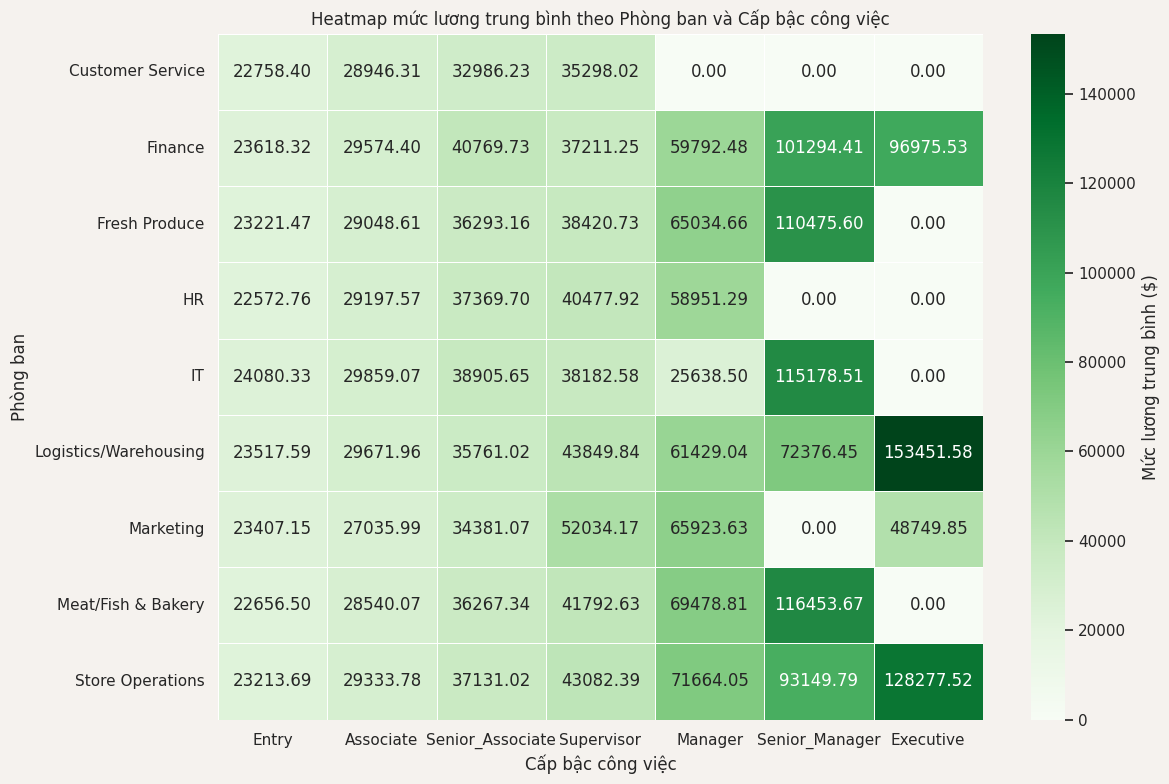

In [ ]:
# Calculate average salary for each combination of Department and Job_Level
average_salary_by_dep_job = df_2024.groupby(['Department', 'Job_Level'])['Base_Salary_Annual'].mean().reset_index()
average_salary_by_dep_job.columns = ['Department', 'Job_Level', 'Average_Salary']

# Create a pivot table for the heatmap
heatmap_data_avg_salary = average_salary_by_dep_job.pivot_table(
    index='Department',
    columns='Job_Level',
    values='Average_Salary'
).fillna(0) # Fill NaN with 0 for combinations with no employees

# Get the sorted order of Job_Level by average salary
sorted_job_levels = average_salary_by_job.sort_values(by='Average Salary', ascending=True)['Job_Level'].tolist()

# Reindex the columns of the heatmap data to apply the sorted order
heatmap_data_avg_salary = heatmap_data_avg_salary[sorted_job_levels]

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_avg_salary, annot=True, fmt=".2f", cmap="Greens", linewidths=.5, cbar_kws={'label': 'Mức lương trung bình ($)'})
plt.title('Heatmap mức lương trung bình theo Phòng ban và Cấp bậc công việc')
plt.xlabel('Cấp bậc công việc')
plt.ylabel('Phòng ban')
plt.tight_layout()
plt.show()

In [ ]:
# Phân tích tăng trưởng lương trung bình theo Cấp bậc công việc
# Sort job levels by their average salary in ascending order for consistent percentage change calculation
sorted_job_levels_avg_salary = average_salary_by_job.sort_values(by='Average Salary', ascending=True)

# Calculate the percentage increase from one job level to the next
salary_growth_data = []

for i in range(1, len(sorted_job_levels_avg_salary)):
    current_level = sorted_job_levels_avg_salary.iloc[i]
    previous_level = sorted_job_levels_avg_salary.iloc[i-1]

    growth_percentage = ((current_level['Average Salary'] - previous_level['Average Salary']) / previous_level['Average Salary']) * 100

    salary_growth_data.append({
        'Job_Level_From': previous_level['Job_Level'],
        'Job_Level_To': current_level['Job_Level'],
        'Percentage_Growth': growth_percentage
    })

salary_growth_df = pd.DataFrame(salary_growth_data)
display(salary_growth_df)

,Job_Level_From,Job_Level_To,Percentage_Growth
0,Entry,Associate,25.900505
1,Associate,Senior_Associate,25.290988
2,Senior_Associate,Supervisor,15.571147
3,Supervisor,Manager,54.402608
4,Manager,Senior_Manager,41.264210
5,Senior_Manager,Executive,20.378947


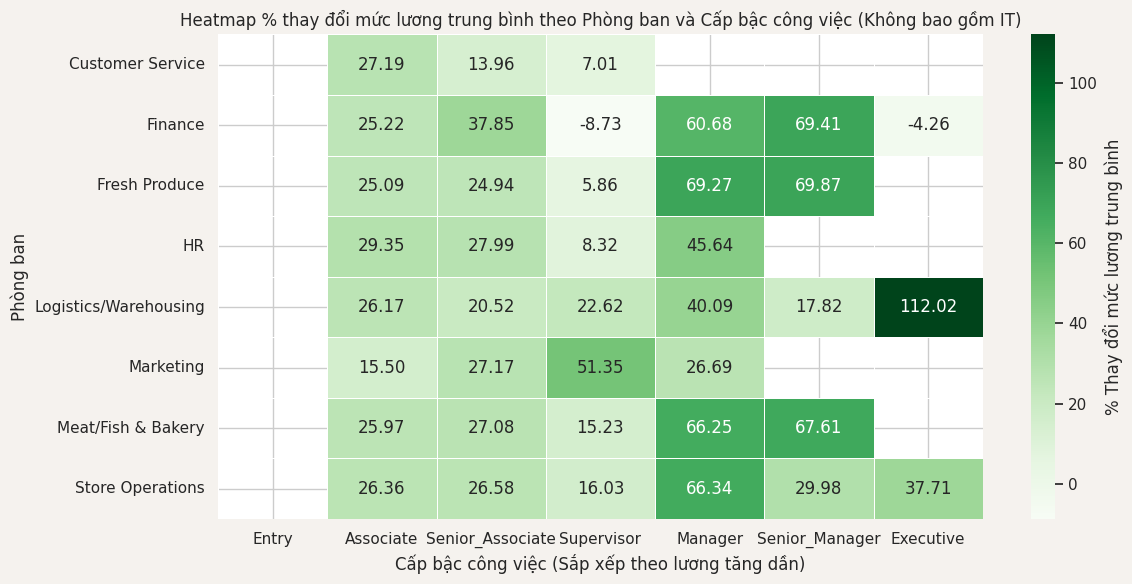

In [ ]:

heatmap_data_avg_salary_unfilled = average_salary_by_dep_job.pivot_table(
    index='Department',
    columns='Job_Level',
    values='Average_Salary'
)

# Ensure the columns are in the desired sorted order (Entry to Executive by average salary)
# Use the 'sorted_job_levels' from the previous sorted heatmap
heatmap_data_avg_salary_sorted_cols = heatmap_data_avg_salary_unfilled[sorted_job_levels]

# Calculate the percentage change across job levels for each department
# NaN values will propagate correctly here if a job level is missing.
salary_change_percent_df = heatmap_data_avg_salary_sorted_cols.pct_change(axis=1, fill_method=None) * 100

# Replace specific values that the user wants to exclude (-100% for drops to 0, inf for jumps from 0) with NaN
salary_change_percent_df.replace([-100.0, float('inf'), float('-inf')], float('nan'), inplace=True)

# Exclude 'IT' department as requested do department có cách phân cấp level khác so với các phòng ban còn lại
salary_change_percent_df_filtered = salary_change_percent_df.drop('IT', errors='ignore')

# Plotting the heatmap of percentage salary change
plt.figure(figsize=(12, 6))
sns.heatmap(salary_change_percent_df_filtered, annot=True, fmt=".2f", cmap="Greens", linewidths=.5, cbar_kws={'label': '% Thay đổi mức lương trung bình'})
plt.title('Heatmap % thay đổi mức lương trung bình theo Phòng ban và Cấp bậc công việc (Không bao gồm IT)')
plt.xlabel('Cấp bậc công việc (Sắp xếp theo lương tăng dần)')
plt.ylabel('Phòng ban')
plt.tight_layout()
plt.show()

In [ ]:
# Filter data for 'IT' department
it_department_df = df_2024[df_2024['Department'] == 'IT']

# Calculate average salary by Job_Level for 'IT' department
avg_salary_it_by_job_level = it_department_df.groupby('Job_Level')['Base_Salary_Annual'].mean().reset_index()
avg_salary_it_by_job_level.columns = ['Job_Level', 'Average Salary']

# Sort job levels by average salary in ascending order
sorted_avg_salary_it = avg_salary_it_by_job_level.sort_values(by='Average Salary', ascending=True)

print("Mức lương trung bình theo cấp bậc trong phòng ban IT:")
display(sorted_avg_salary_it)

# Calculate the percentage change in average salary between consecutive job levels
percentage_change_it = []

for i in range(1, len(sorted_avg_salary_it)):
    current_level_salary = sorted_avg_salary_it.iloc[i]['Average Salary']
    previous_level_salary = sorted_avg_salary_it.iloc[i-1]['Average Salary']
    job_level_from = sorted_avg_salary_it.iloc[i-1]['Job_Level']
    job_level_to = sorted_avg_salary_it.iloc[i]['Job_Level']

    if previous_level_salary > 0:
        change = ((current_level_salary - previous_level_salary) / previous_level_salary) * 100
    else:
        change = float('inf') # Handle division by zero if previous salary is 0

    percentage_change_it.append({
        'Job_Level_From': job_level_from,
        'Job_Level_To': job_level_to,
        'Percentage_Change': change
    })

percentage_change_it_df = pd.DataFrame(percentage_change_it)

print("\n% thay đổi mức lương trung bình theo cấp bậc trong phòng ban IT:")
display(percentage_change_it_df)

Mức lương trung bình theo cấp bậc trong phòng ban IT:


,Job_Level,Average Salary
1,Entry,24080.325487
2,Manager,25638.500000
0,Associate,29859.065217
5,Supervisor,38182.580000
3,Senior_Associate,38905.647812
4,Senior_Manager,115178.510000



% thay đổi mức lương trung bình theo cấp bậc trong phòng ban IT:


,Job_Level_From,Job_Level_To,Percentage_Change
0,Entry,Manager,6.470737
1,Manager,Associate,16.461826
2,Associate,Supervisor,27.876006
3,Supervisor,Senior_Associate,1.893711
4,Senior_Associate,Senior_Manager,196.045732


**CHÍNH SÁCH LƯƠNG**
- Chính sách lương:
  - Mỗi cấp bậc có dải lương khá rộng chứ không có mức lương cố định cho từng cấp bậc
- Chính sách lương tại các phòng ban:

  - Bộ phận IT và Finance là 2 bộ phận có mức lương cao nhất.
  - Khá thú vị là các vị trí có mức lương trung bình cao nhất lại là cấp Executive thuộc Logistics/Warehousing và Store Operations.
  - Công ty có tăng trưởng lương theo cấp độ công việc khá tốt, đặc biệt là có mức tăng trưởng rất cao khi từ vị trị Supervisor chuyển lên cấp Manager (tăng trung bình 54.40%) và khi từ cấp Manager lên tới cấp Senior Manager (tăng trung bình 41.26%)
  - Tuy nhiên mức tăng trưởng này không đồng đều ở các phòng ban, một số phòng ban có mức tăng lương cực kỳ cao khi thay đổi cấp bậc và một số còn lại là mức tăng đều đặn dần. Nhưng nhìn chung việc thay đổi từ lên vị trí lãnh đạo (Cấp Manager/ Senior Manager) luôn tạo ra sự bứt phá về lương cho nhân sự nói chung.
  - IT là bộ phận có mức lương trung bình cao nhất của hệ thống và có cấp bậc công việc khác biệt so với các phòng ban khác.
      - Người giữ cấp bậc Senior Manager tại IT có mức lương cao gấp ~ 3 lần người ở dưới 1 bậc.



## **5.2 Phân tích đánh giá công việc**


### **5.2.1 Đánh giá hiệu suất công việc theo thời gian và phòng ban**

In [ ]:
# 1. Prepare df_em for employee-level metrics

# Convert 'Exit_Date' to 'Attrition_Tag': 1 if exited, 0 otherwise
df['Attrition_Tag'] = df['Exit_Date'].notnull().astype(int)

# Convert boolean flags to numeric (1 for True, 0 for False)
# First, fill any NaN values in Promotion_Flag and Salary_Increase_Flag with False
# This handles cases where merges might have introduced NaNs into these boolean columns
df['Promotion_Flag_Numeric'] = df['Promotion_Flag'].fillna(False).astype(int)
df['Salary_Increase_Flag_Numeric'] = df['Salary_Increase_Flag'].fillna(False).astype(int)

# Ensure Year_Month is datetime and extract Year
df['Year_Month'] = pd.to_datetime(df_em['Year_Month'])
df['Year'] = df['Year_Month'].dt.year

# Display head to check new columns
print("df with new flags and Year column:")
display(df[['Employee_Id', 'Exit_Date', 'Attrition_Tag', 'Promotion_Flag', 'Promotion_Flag_Numeric', 'Salary_Increase_Flag', 'Salary_Increase_Flag_Numeric', 'Year_Month', 'Year']].head())

df with new flags and Year column:


,Employee_Id,Exit_Date,Attrition_Tag,Promotion_Flag,Promotion_Flag_Numeric,Salary_Increase_Flag,Salary_Increase_Flag_Numeric,Year_Month,Year
0,EMP000001,2022-04-13,1,False,0,False,0,2022-01-01,2022.0
1,EMP000001,2022-04-13,1,False,0,False,0,2022-02-01,2022.0
2,EMP000001,2022-04-13,1,False,0,False,0,2022-03-01,2022.0
3,EMP000001,2022-04-13,1,False,0,False,0,2022-04-01,2022.0
4,EMP000002,NaT,0,False,0,False,0,2022-01-01,2022.0


In [ ]:
# 2. Aggregate employee career metrics
# Group by Employee_Id and Department to get career-long summaries

employee_career_summary = df.groupby(['Employee_Id', 'Department']).agg(
    Attrition_Tag=('Attrition_Tag', 'max'), # Max to get 1 if they ever exited
    Avg_Age=('Age', 'first'), # Age is static per employee
    Median_Annual_Salary=('Base_Salary_Annual', 'median'), # As requested, use median for salary
    Total_Promotions=('Promotion_Flag_Numeric', 'sum'),
    Total_Salary_Increases=('Salary_Increase_Flag_Numeric', 'sum'),
    Avg_Performance_Rating=('Performance_Rating', 'mean'),
    Avg_Training_Hours=('Training_Hours', 'mean'),
    Avg_Overtime_Hours=('Overtime_Hours', 'mean'),
    Avg_Absenteeism_Days=('Absenteeism_Days', 'mean'),
    Avg_Employee_Satisfaction=('Employee_Satisfaction', 'mean'),
    Avg_Engagement_Index=('Engagement_Index', 'mean'),
    Avg_Manager_Evaluation=('Manager_Evaluation', 'mean'),
    Avg_Productivity_Index=('Productivity_Index', 'mean')
).reset_index()

# Round numerical columns for display
for col in employee_career_summary.columns:
    if employee_career_summary[col].dtype == 'float64':
        employee_career_summary[col] = employee_career_summary[col].round(2)

print("Employee Career Summary (first 5 rows):")
display(employee_career_summary.head())

Employee Career Summary (first 5 rows):


,Employee_Id,Department,Attrition_Tag,Avg_Age,Median_Annual_Salary,Total_Promotions,Total_Salary_Increases,Avg_Performance_Rating,Avg_Training_Hours,Avg_Overtime_Hours,Avg_Absenteeism_Days,Avg_Employee_Satisfaction,Avg_Engagement_Index,Avg_Manager_Evaluation,Avg_Productivity_Index
0,EMP000001,Store Operations,1,23,25745.40,0,0,3.96,4.50,13.75,0.50,7.72,7.95,4.12,1.48
1,EMP000002,Store Operations,0,26,39408.57,0,0,3.97,4.94,13.42,0.72,7.47,7.32,3.97,1.49
2,EMP000003,Store Operations,0,38,29319.94,0,0,4.16,5.11,15.08,0.83,8.09,7.88,4.12,1.58
3,EMP000004,Store Operations,0,33,43979.88,0,2,3.98,5.75,13.92,0.61,7.34,7.34,3.93,1.49
4,EMP000005,Store Operations,0,24,23560.19,0,1,4.08,1.78,9.00,0.44,7.91,7.96,4.03,1.54


In [ ]:
# Calculate overall average performance rating per department
overall_avg_performance_by_department = employee_career_summary.groupby('Department')['Avg_Performance_Rating'].mean().reset_index()
overall_avg_performance_by_department.columns = ['Department', 'Average Performance Rating']

print("Top 10 phòng ban có điểm đánh giá hiệu suất trung bình cao nhất:")
display(overall_avg_performance_by_department.sort_values(by='Average Performance Rating', ascending=False).head(10))

Top 10 phòng ban có điểm đánh giá hiệu suất trung bình cao nhất:


,Department,Average Performance Rating
8,Store Operations,3.763106
0,Customer Service,3.724336
3,HR,3.668531
1,Finance,3.665907
4,IT,3.661872
6,Marketing,3.660071
7,Meat/Fish & Bakery,3.659213
2,Fresh Produce,3.658349
5,Logistics/Warehousing,3.590435


**INSIGHT**
- Mức đánh giá hiệu suất trung bình ~ 3.7
- Điểm đánh giá hiệu suất có xu hướng đạt đỉnh vào những tháng cuối năm và đầu năm và sụt giảm vào khoảng quý 3.
- Store Operations & Customer Service là 2 phòng ban có hiệu suất trung bình cao nhất.
- Tất cả các phòng ban đều có chung pattern về dao động điểm đánh giá hiệu suất trong năm.

### **5.2.2 Mối tương quan giữa Đào tạo và Hiệu suất công việc**

In [ ]:
employee_career_summary.head(2)

,Employee_Id,Department,Attrition_Tag,Avg_Age,Median_Annual_Salary,Total_Promotions,Total_Salary_Increases,Avg_Performance_Rating,Avg_Training_Hours,Avg_Overtime_Hours,Avg_Absenteeism_Days,Avg_Employee_Satisfaction,Avg_Engagement_Index,Avg_Manager_Evaluation,Avg_Productivity_Index
0,EMP000001,Store Operations,1,23,25745.40,0,0,3.96,4.50,13.75,0.50,7.72,7.95,4.12,1.48
1,EMP000002,Store Operations,0,26,39408.57,0,0,3.97,4.94,13.42,0.72,7.47,7.32,3.97,1.49


In [ ]:
correlation_training_performance = employee_career_summary['Avg_Training_Hours'].corr(employee_career_summary['Avg_Performance_Rating'])
print(f"Hệ số tương quan giữa Training_Hours và Performance_Rating: {correlation_training_performance:.2f}")

Hệ số tương quan giữa Training_Hours và Performance_Rating: 0.55


Điểm đánh giá hiệu suất trung bình theo nhóm đào tạo:


,Training_Group,Avg_Performance_Rating
0,High Training (Q4),4.014131
1,Low Training (Q1),3.594863
2,Medium Training (Q2-Q3),3.573382


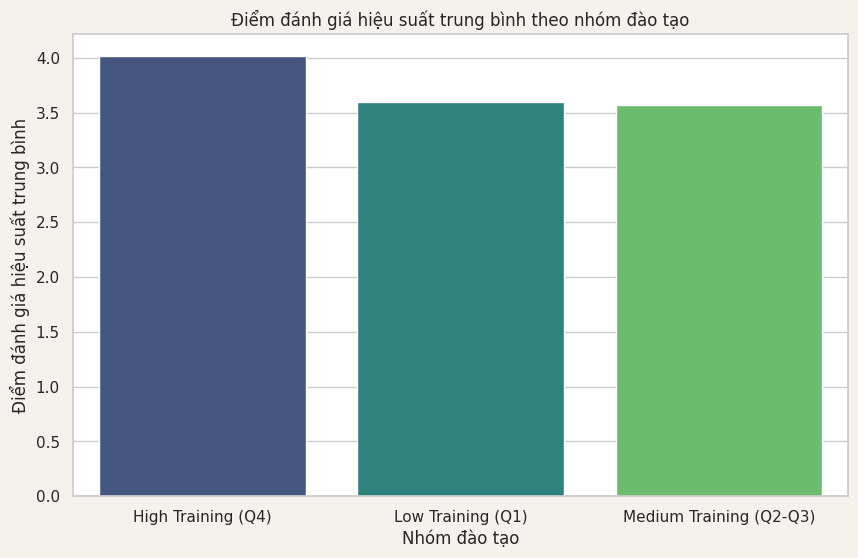

In [ ]:
# 1. Define Training Cohorts based on quartiles of Training_Hours

# Calculate quartiles for Training_Hours
quartiles = employee_career_summary['Avg_Training_Hours'].quantile([0.25, 0.75])
Q1 = quartiles[0.25]
Q3 = quartiles[0.75]

# Define a function to assign employees to training groups
def assign_training_group(hours):
    if hours <= Q1:
        return 'Low Training (Q1)'
    elif hours > Q3:
        return 'High Training (Q4)'
    else:
        return 'Medium Training (Q2-Q3)'

# Apply the function to create a new 'Training_Group' column
employee_career_summary['Training_Group'] = employee_career_summary['Avg_Training_Hours'].apply(assign_training_group)

# 2. Compare average Performance_Rating by group
avg_performance_by_training_group = employee_career_summary.groupby('Training_Group')['Avg_Performance_Rating'].mean().reset_index()
avg_performance_by_training_group = avg_performance_by_training_group.sort_values(by='Avg_Performance_Rating', ascending=False)

print("Điểm đánh giá hiệu suất trung bình theo nhóm đào tạo:")
display(avg_performance_by_training_group)

# 3. Visualize the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Training_Group', y='Avg_Performance_Rating', hue='Training_Group', data=avg_performance_by_training_group, palette='vYlOrBr', legend=False)
plt.title('Điểm đánh giá hiệu suất trung bình theo nhóm đào tạo')
plt.xlabel('Nhóm đào tạo')
plt.ylabel('Điểm đánh giá hiệu suất trung bình')
plt.show()

In [ ]:
df_employees.columns

Index(['Employee_Id', 'Full_Name', 'Age', 'Education_Level', 'Hire_Date',
       'Exit_Date', 'Department', 'Job_Role', 'Job_Level', 'Employment_Type',
       'Base_Salary_Annual', 'Store_Location', 'Store_Location_Latitude',
       'Store_Location_Longitude', 'Store_Id', 'Manager_Id', 'Manager_Name',
       'Manager_Status', 'Tenure_Months'],
      dtype='object')

In [ ]:
employee_career_summary_full = employee_career_summary.merge(df_employees[['Employee_Id', 'Full_Name', 'Job_Level', 'Job_Role','Store_Id', 'Hire_Date',
       'Exit_Date']], on='Employee_Id', how='left')

In [ ]:
fig = px.scatter(employee_career_summary_full,
                 x='Avg_Training_Hours',
                 y='Avg_Performance_Rating',
                 color='Job_Level',
                 hover_data=['Full_Name', 'Department', 'Job_Level'],
                 trendline='ols', # Add OLS (Ordinary Least Squares) regression line
                 title='Biểu đồ phân tán: Hiệu suất công việc vs Giờ đào tạo (theo Cấp bậc công việc)',
                 labels={'Training_Hours': 'Giờ đào tạo',
                         'Performance_Rating': 'Điểm đánh giá hiệu suất'})
fig.show()

In [ ]:
fig = px.scatter(employee_career_summary_full,
                 x='Avg_Training_Hours',
                 y='Avg_Performance_Rating',
                 color='Job_Role',
                 hover_data=['Full_Name', 'Department', 'Job_Role'],
                 trendline='ols', # Add OLS (Ordinary Least Squares) regression line
                 title='Biểu đồ phân tán: Hiệu suất công việc vs Giờ đào tạo (theo Vị trí công việc)',
                 labels={'Training_Hours': 'Giờ đào tạo',
                         'Performance_Rating': 'Điểm đánh giá hiệu suất'})
fig.show()

In [ ]:
correlation_by_job_role = employee_career_summary_full.groupby('Job_Role').apply(lambda x: x['Avg_Training_Hours'].corr(x['Avg_Performance_Rating']))

# Convert the Series to a DataFrame and rename the column for clarity
correlation_by_job_role = correlation_by_job_role.reset_index()
correlation_by_job_role.columns = ['Job_Role', 'Correlation_Training_Performance']

# Sort by correlation in descending order and get the top 5
top_5_job_roles_correlation = correlation_by_job_role.sort_values(by='Correlation_Training_Performance', ascending=False).head(5)

print("Top 5 Job Roles with highest correlation between Average Training Hours and Average Performance Rating:")
display(top_5_job_roles_correlation)

Top 5 Job Roles with highest correlation between Average Training Hours and Average Performance Rating:


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning:

Degrees of freedom <= 0 for slice

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning:

divide by zero encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipykernel_413/2853666093.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,Job_Role,Correlation_Training_Performance
7,Deli Manager,1.000000
49,Vice President,1.000000
27,Marketing Supervisor,0.990356
23,IT Supervisor,0.977154
6,Customer Service Supervisor,0.950803


### **5.2.3 Độ tuổi và Hiệu suất công việc**

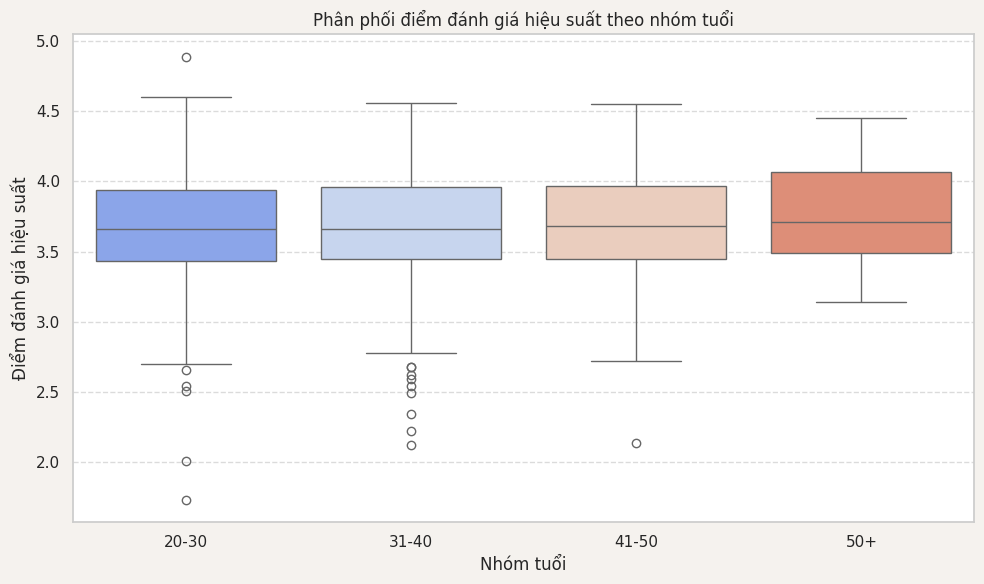

In [ ]:
# Define age bins and labels
age_bins = [0, 30, 40, 50, df['Age'].max()]
age_labels = ['20-30', '31-40', '41-50', '50+']

# Create 'Age_Group' column
employee_career_summary_full['Age_Group'] = pd.cut(employee_career_summary_full['Avg_Age'], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

# Order the age groups for plotting
age_group_order = ['20-30', '31-40', '41-50', '50+']
employee_career_summary_full['Age_Group'] = pd.Categorical(employee_career_summary_full['Age_Group'], categories=age_group_order, ordered=True)

# Create the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Age_Group', y='Avg_Performance_Rating', hue='Age_Group', data=employee_career_summary_full, palette='coolwarm', legend=False)
plt.title('Phân phối điểm đánh giá hiệu suất theo nhóm tuổi')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Điểm đánh giá hiệu suất')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
age_group_performance_stats = employee_career_summary_full.groupby('Age_Group')['Avg_Performance_Rating'].agg(
    mean_performance='mean',
    sample_size='count',
    std_dev_performance='std'
).reset_index()

display(age_group_performance_stats)

/tmp/ipykernel_413/2012987438.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Age_Group,mean_performance,sample_size,std_dev_performance
0,20-30,3.679182,3107,0.331325
1,31-40,3.692275,2945,0.325672
2,41-50,3.705499,942,0.324598
3,50+,3.748152,92,0.338922


### **5.2.4 Quản lý và hiệu suất công việc theo nhóm**

In [ ]:

# Rank descending by Avg_Team_Performance and get Top 10
top_10_managers = manager_performance_summary.sort_values(by='Avg_Team_Performance', ascending=False).head(10)

print("\nTop 10 Managers by Average Team Performance:")
display(top_10_managers.reset_index(drop=True))



Top 10 Managers by Average Team Performance:


,Manager_Id,Manager_Name,Avg_Team_Performance,Team_Size,Attrition_Rate_of_Team
0,EMP001823,Nicholas Fitzgerald,3.796064,138,10.144928
1,EMP000529,Melissa Bishop,3.791658,142,19.014085
2,EMP000240,Briana Murray,3.790814,134,17.164179
3,EMP002493,Eric Williams,3.775807,137,9.489051
4,EMP000053,Rebecca Valencia,3.775310,135,12.592593
5,EMP000121,Jamie Walton,3.773432,133,14.285714
6,EMP002684,David James,3.771944,137,15.328467
7,EMP001224,Raymond Quinn,3.771790,136,16.911765
8,EMP002163,Mr. William Ward,3.771781,134,9.701493
9,EMP001026,Brandon Kelly,3.767891,133,15.037594


#### Hiệu suất trung bình đội ngũ năm 2024

In [ ]:
df_2024 = df[df['Year_Month'].dt.year == 2024].copy()

# Calculate Average Performance Rating for each manager's team in 2024
manager_avg_performance_2024 = df_2024.groupby(['Manager_Id', 'Manager_Name'])['Performance_Rating'].mean().reset_index()
manager_avg_performance_2024.rename(columns={'Performance_Rating': 'Avg_Team_Performance_2024'}, inplace=True)

# Calculate Team Size for each manager in 2024
manager_team_size_2024 = df_2024.groupby(['Manager_Id', 'Manager_Name'])['Employee_Id'].nunique().reset_index()
manager_team_size_2024.rename(columns={'Employee_Id': 'Team_Size_2024'}, inplace=True)

# Calculate Attrition Rate for each manager's team in 2024
# For attrition, we need to consider employees active in 2024 who exited in 2024.
# First, identify all employees managed by each manager within 2024
unique_employee_manager_2024 = df_2024[['Employee_Id', 'Manager_Id', 'Manager_Name']].drop_duplicates()

total_managed_employees_2024 = unique_employee_manager_2024.groupby(['Manager_Id', 'Manager_Name'])['Employee_Id'].nunique().reset_index()
total_managed_employees_2024.rename(columns={'Employee_Id': 'Total_Managed_Employees_2024'}, inplace=True)

# Employees who exited in 2024 under each manager
exited_employees_managed_2024 = df_2024[
    df_2024['Exit_Date'].dt.year == 2024
].groupby(['Manager_Id', 'Manager_Name'])['Employee_Id'].nunique().reset_index()
exited_employees_managed_2024.rename(columns={'Employee_Id': 'Exited_Employees_2024'}, inplace=True)

# Merge to calculate attrition rate for 2024
manager_attrition_2024 = pd.merge(total_managed_employees_2024, exited_employees_managed_2024, on=['Manager_Id', 'Manager_Name'], how='left')
manager_attrition_2024['Exited_Employees_2024'] = manager_attrition_2024['Exited_Employees_2024'].fillna(0) # Fill NaN for managers with no exited employees
manager_attrition_2024['Attrition_Rate_of_Team_2024'] = (manager_attrition_2024['Exited_Employees_2024'] / manager_attrition_2024['Total_Managed_Employees_2024']) * 100

# Merge all 2024 data into a single DataFrame
manager_performance_summary_2024 = pd.merge(manager_avg_performance_2024, manager_team_size_2024, on=['Manager_Id', 'Manager_Name'], how='left')
manager_performance_summary_2024 = pd.merge(manager_performance_summary_2024, manager_attrition_2024[['Manager_Id', 'Manager_Name', 'Attrition_Rate_of_Team_2024']], on=['Manager_Id', 'Manager_Name'], how='left')

# Rank descending by Avg_Team_Performance_2024 and get Top 10
top_10_managers_2024 = manager_performance_summary_2024.sort_values(by='Avg_Team_Performance_2024', ascending=False).head(10)

print("\nTop 10 Managers by Average Team Performance in 2024:")
display(top_10_managers_2024.reset_index(drop=True))


Top 10 Managers by Average Team Performance in 2024:


,Manager_Id,Manager_Name,Avg_Team_Performance_2024,Team_Size_2024,Attrition_Rate_of_Team_2024
0,EMP001823,Nicholas Fitzgerald,3.809198,135,4.444444
1,EMP000529,Melissa Bishop,3.801039,135,5.185185
2,EMP001224,Raymond Quinn,3.795920,126,3.174603
3,EMP000121,Jamie Walton,3.790526,130,6.153846
4,EMP001131,Michelle Walls,3.783940,135,7.407407
5,EMP002456,Jennifer Moore,3.779615,128,5.468750
6,EMP001026,Brandon Kelly,3.776868,129,3.100775
7,EMP002493,Eric Williams,3.768649,130,3.076923
8,EMP000240,Briana Murray,3.767923,126,6.349206
9,EMP000053,Rebecca Valencia,3.767347,130,5.384615


**INSIGHT:**
- Nhìn chung các nhân sự khi được đào tạo càng nhiều sẽ càng có Performance Rating cao hơn, đặc biệt ở các vị trí như Marketing Supervisor hay Customer Service Supervisor.
- Nhân sự tại công ty có độ tuổi khá trẻ (75% < 37 tuổi) tuy nhiên nhóm người có Performance Rating cao nhất lại thuộc về nhóm 50+. Và không có gì ngạc nhiên khi lứa 20-30 là lứa nhân sự đông nhất tại công ty lại có rating trung bình thấp nhất, với nhiều người ở mức rất thấp chỉ 1-2.5.
- Xu hướng Performance Rating tăng theo thời gian.
- Manager có team làm việc hiệu quả nhất là **Nicholas Fitzgerald** quản lý 135 nhân sự với điểm đánh giá trung bình cả team là 3.8 và tỷ lệ rời bỏ cũng 4.44% (năm 2024)


## **5.3 Mức độ hài lòng của nhân viên**




In [ ]:
employee_career_summary_full.columns

Index(['Employee_Id', 'Department', 'Attrition_Tag', 'Avg_Age',
       'Median_Annual_Salary', 'Total_Promotions', 'Total_Salary_Increases',
       'Avg_Performance_Rating', 'Avg_Training_Hours', 'Avg_Overtime_Hours',
       'Avg_Absenteeism_Days', 'Avg_Employee_Satisfaction',
       'Avg_Engagement_Index', 'Avg_Manager_Evaluation', 'Training_Group',
       'Full_Name', 'Job_Level', 'Job_Role', 'Store_Id', 'Tenure_Months',
       'Manager_Id', 'Manager_Name'],
      dtype='object')

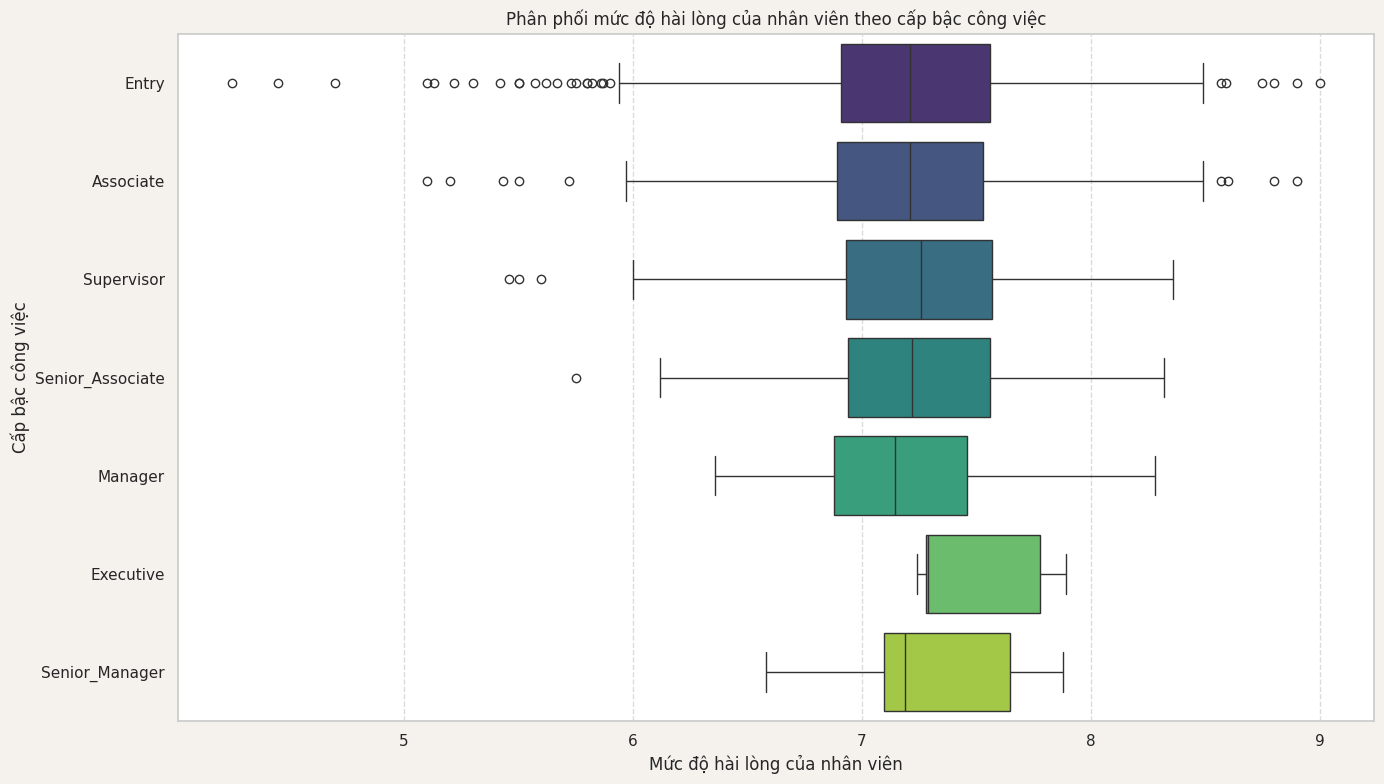

In [ ]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='Avg_Employee_Satisfaction', y='Job_Level', hue='Job_Level', data=employee_career_summary_full.sort_values(by='Avg_Employee_Satisfaction', ascending=False), palette='viridis', legend=False)
plt.title('Phân phối mức độ hài lòng của nhân viên theo cấp bậc công việc')
plt.xlabel('Mức độ hài lòng của nhân viên')
plt.ylabel('Cấp bậc công việc')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

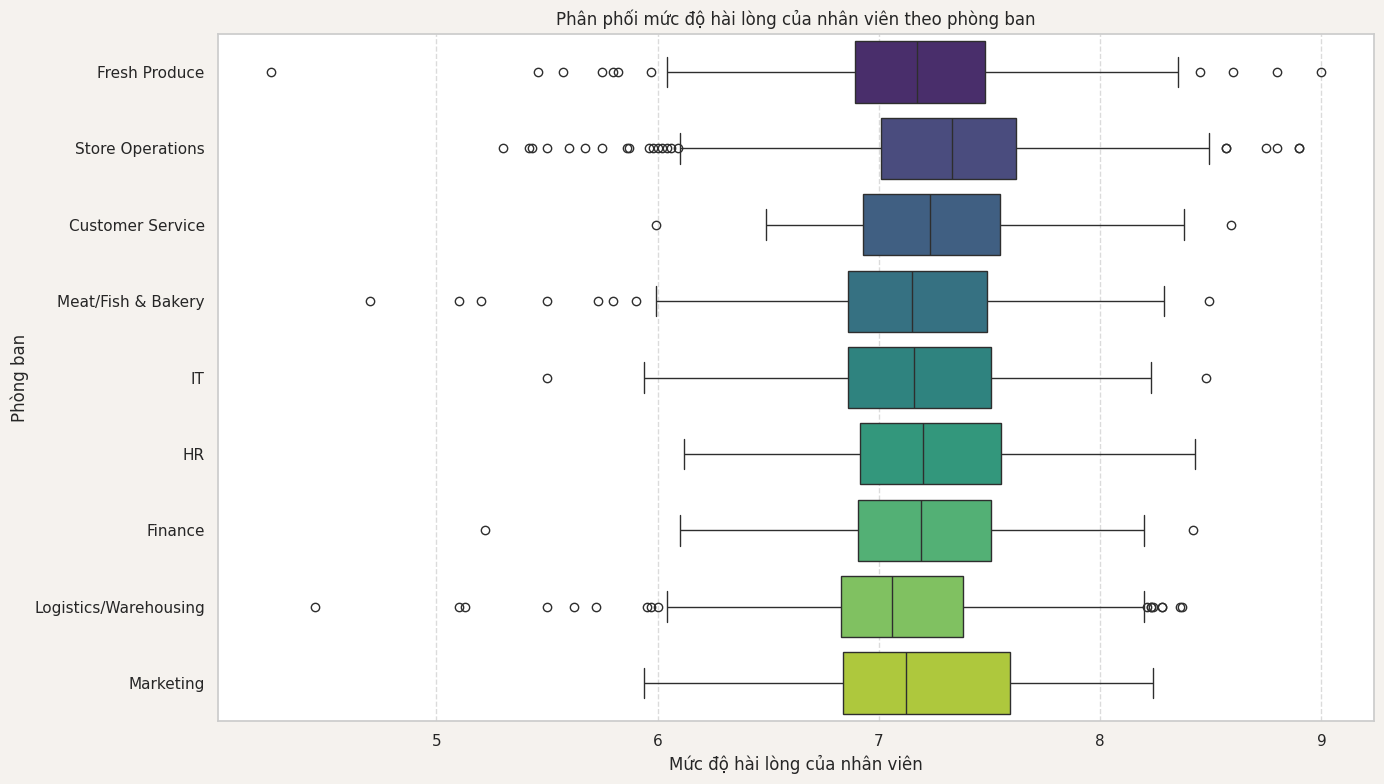

In [ ]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='Avg_Employee_Satisfaction', y='Department', hue='Department', data=employee_career_summary_full.sort_values(by='Avg_Employee_Satisfaction', ascending=False), palette='viridis', legend=False)
plt.title('Phân phối mức độ hài lòng của nhân viên theo phòng ban')
plt.xlabel('Mức độ hài lòng của nhân viên')
plt.ylabel('Phòng ban')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
employee_career_summary_full['Avg_Employee_Satisfaction'].groupby(df['Department']).mean().sort_values(ascending=False)

,Avg_Employee_Satisfaction
Department,
Store Operations,7.309391
Customer Service,7.252657
HR,7.227488
Finance,7.203628
IT,7.189863
Marketing,7.189643
Fresh Produce,7.185666
Meat/Fish & Bakery,7.178096
Logistics/Warehousing,7.109786


In [ ]:
df['Year_Month'] = pd.to_datetime(df['Year_Month'])
df['Year'] = df['Year_Month'].dt.year
df['Year_Month'] = df['Year_Month'].dt.strftime('%Y-%m')
avg_satisfaction_by_dept_month = df.groupby(['Department', 'Year_Month'])['Employee_Satisfaction'].mean().reset_index()

# Pivot the table for heatmap
heatmap_data_satisfaction = avg_satisfaction_by_dept_month.pivot_table(
    index='Department',
    columns='Year_Month',
    values='Employee_Satisfaction'
)

# Ensure Year_Month columns are sorted chronologically if not already
heatmap_data_satisfaction = heatmap_data_satisfaction.sort_index(axis=1)

fig = go.Figure(data=go.Heatmap(
        z=heatmap_data_satisfaction.values,
        x=heatmap_data_satisfaction.columns,
        y=heatmap_data_satisfaction.index,
        colorscale='Viridis',
        colorbar_title='Mức độ hài lòng trung bình'))

fig.update_layout(
    title='Heatmap: Xu hướng hài lòng của nhân viên theo Phòng ban và Tháng',
    xaxis_title='Năm-Tháng',
    yaxis_title='Phòng ban',
    xaxis={'type': 'category'},
    yaxis={'type': 'category'}
)
fig.show()

**INSIGHT:**
- Mức độ hài lòng của nhân viên đối với công ty nhìn chung cải thiện theo thời gian.
- Đáng ngạc nhiên là bộ phận Store Operations là bộ phận có vẻ stress nhất lại là bộ phận có mức độ hài lòng trung bình cao nhất.
- Nhóm phòng ban Meat/Fish & Bakery; Marketing; Logistics & Warehousing cho thấy mức độ hài lòng khá thấp. Đây có lẽ cũng là 1 lý do khiến Marketing và Logistics/Warehousing có xu hướng rời bỏ công ty cao.
- Cấp Executive cảm thấy hài lòng cao nhất trong khi Manager lại là nhóm người có mức hài lòng thấp nhất trong tất cả các cấp bậc. Có vẻ vai trò manager có vai trò trách nhiệm nặng nề khiến họ thấy kém hài lòng.

## **5.4 Productivity Index**

In [ ]:
productivity_by_job_role = employee_career_summary_full.groupby('Job_Role').agg(
    Average_Productivity_Index=('Avg_Productivity_Index', 'mean'),
    Average_Performance_Ratings=('Avg_Performance_Rating', 'mean'),
    Employee_Count=('Employee_Id', 'count')
).reset_index()
productivity_by_job_role = productivity_by_job_role.sort_values(by='Average_Productivity_Index', ascending=False)

print("Chỉ số năng suất trung bình, Điểm đánh giá hiệu suất trung bình và Số lượng nhân viên theo vai trò công việc:")
display(productivity_by_job_role.head())

Chỉ số năng suất trung bình, Điểm đánh giá hiệu suất trung bình và Số lượng nhân viên theo vai trò công việc:


,Job_Role,Average_Productivity_Index,Average_Performance_Ratings,Employee_Count
14,Fresh Foods Director,1.560,4.120,1
49,Vice President,1.510,4.025,2
28,Meat/Fish & Bakery Director,1.450,3.910,1
27,Marketing Supervisor,1.435,3.865,4
48,Supply Chain Director,1.415,3.825,4


In [ ]:
# Get the top 10 job roles by Average_Productivity_Index
top_10_productivity_roles = productivity_by_job_role.head(10)

fig = px.scatter(top_10_productivity_roles,
                 x='Average_Productivity_Index',
                 y='Average_Performance_Ratings',
                 text='Job_Role',
                 size='Employee_Count',
                 color='Job_Role',
                 hover_name='Job_Role',
                 title='Mối quan hệ giữa hiệu suất lao động và xếp hạng lao động của 10 vai trò công việc hàng đầu',
                 labels={
                     'Average_Productivity_Index': 'Chỉ số hiệu suất trung bình',
                     'Average_Performance_Ratings': 'Xếp hạng hiệu quả lao động trung bình',
                     'Employee_Count': 'Số lượng nhân viên'
                 })

fig.update_traces(textposition='top center')
fig.update_layout(showlegend=False)
fig.show()

In [ ]:
productivity_by_job_level = employee_career_summary_full.groupby('Job_Level').agg(
    Average_Productivity_Index=('Avg_Productivity_Index', 'mean'),
    Average_Performance_Ratings=('Avg_Performance_Rating', 'mean'),
    Employee_Count=('Employee_Id', 'count')
).reset_index()
productivity_by_job_level = productivity_by_job_level.sort_values(by='Average_Productivity_Index', ascending=False)

print("Chỉ số năng suất trung bình, Điểm đánh giá hiệu suất trung bình và Số lượng nhân viên theo cấp bậc:")
display(productivity_by_job_level)

Chỉ số năng suất trung bình, Điểm đánh giá hiệu suất trung bình và Số lượng nhân viên theo cấp bậc:


,Job_Level,Average_Productivity_Index,Average_Performance_Ratings,Employee_Count
2,Executive,1.432000,3.868000,5
5,Senior_Manager,1.374667,3.750667,15
6,Supervisor,1.363797,3.727005,187
4,Senior_Associate,1.349665,3.699010,717
1,Entry,1.343762,3.687575,3777
0,Associate,1.342420,3.684951,2355
3,Manager,1.326333,3.653667,30


**INSIGHT**
- Có một mối quan hệ thuận chiều giữa Chỉ số năng suất và Điểm đánh giá hiệu suất. Các vai trò công việc có chỉ số năng suất cao hơn cũng có xu hướng có điểm đánh giá hiệu suất cao hơn.
- Fresh Food Director, Vice President, Meat/Fish & Bakery Director nổi bật với cả chỉ số năng suất và điểm đánh giá hiệu quả đều rất tốt.
- Về cấp bậc công việc thì cấp Executive đứng đầu với chỉ số năng suất cao nhất, đạt trung bình 1.43 trong khi Manager có chỉ số năng suất này thấp nhất, vị trí này cũng khá tương đồng khi quan sát chỉ số hài lòng nhân viên (Employee Satisfaction).

## **5.3 Phân tích tỷ lệ nghỉ việc**




### **5.3.1 Tỷ lệ nghỉ việc theo thời gian**

In [ ]:
left = df_2024[df_2024['Exit_Date'].notnull()]
employees_left = left['Employee_Id'].nunique()
Attrition_rate = (employees_left / total_employees) * 100
print(f"Tổng số nhân viên đã rời đi: {employees_left}")
print(f"Tỷ lệ nghỉ việc: {Attrition_rate:.2f}%")

Tổng số nhân viên đã rời đi: 1077
Tỷ lệ nghỉ việc: 15.20%


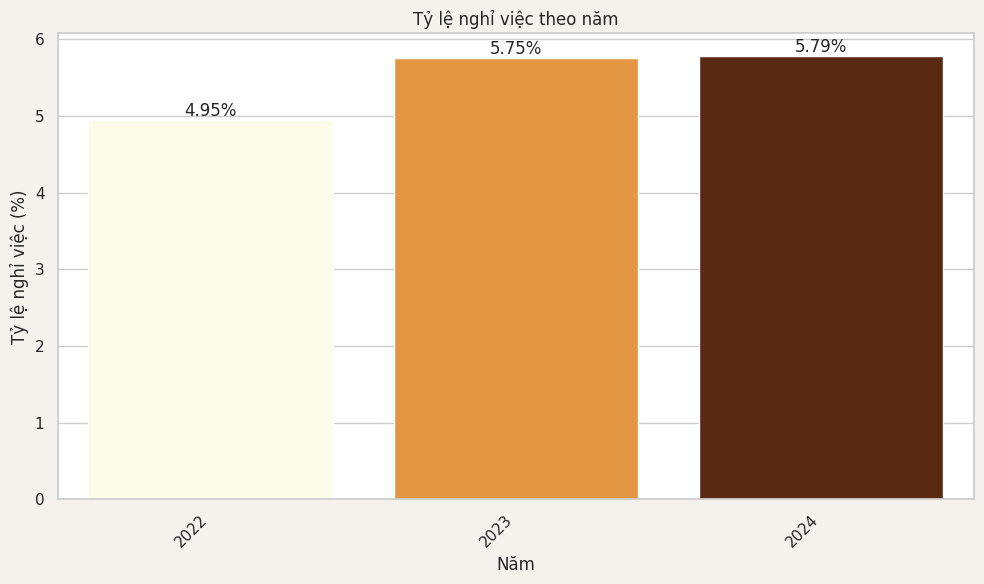

In [ ]:
# Hire_Date and Exit_Date are already datetime objects from previous steps

all_years = range(2022, 2024+1)
attrition_data = []

for year in all_years:
    # Số nhân viên nghỉ việc mỗi năm
    exits_in_year = df_2024[df_2024['Exit_Date'].dt.year == year]['Employee_Id'].nunique()

    # Tính toán Headcount đầu năm và cuối năm
    start_of_year = pd.Timestamp(f'{year}-01-01')
    end_of_year = pd.Timestamp(f'{year}-12-31')

    # Headcount đầu năm
    headcount_start_of_year = df_2024[
        (df_2024['Hire_Date'] <= start_of_year) &
        ((df_2024['Exit_Date'].isnull()) | (df_2024['Exit_Date'] > start_of_year))
    ].shape[0]

    # Headcount cuối năm
    headcount_end_of_year = df_2024[
        (df_2024['Hire_Date'] <= end_of_year) &
        ((df_2024['Exit_Date'].isnull()) | (df_2024['Exit_Date'] > end_of_year))
    ].shape[0]

    # Trung bình headcout mỗi năm
    average_headcount_during_year = (headcount_start_of_year + headcount_end_of_year) / 2

    attrition_rate = 0
    if average_headcount_during_year > 0:
        attrition_rate = (exits_in_year / average_headcount_during_year) * 100

    attrition_data.append({
        'Year': year,
        'Attrition_Rate': attrition_rate,
        'Exits': exits_in_year,
        'Average_Headcount': average_headcount_during_year
    })

attrition_by_year_df = pd.DataFrame(attrition_data)

# Filter out years where there were no active employees or no data relevant to the period before any hires
attrition_by_year_df = attrition_by_year_df[attrition_by_year_df['Average_Headcount'] > 0]

# Plotting the annual attrition rate
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Year', y='Attrition_Rate', data=attrition_by_year_df, palette='YlOrBr', hue='Year', legend=False)
plt.title('Tỷ lệ nghỉ việc theo năm')
plt.xlabel('Năm')
plt.ylabel('Tỷ lệ nghỉ việc (%)')
plt.xticks(rotation=45, ha='right')

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

**INSIGHT**
- Tỷ lệ nghỉ việc chung là 15.20%. Tuy nhiên, khi theo dõi theo năm, tỷ lệ nghỉ việc có xu hướng tăng mỗi năm và năm gần nhất đang ở mức ~ 5.79%. Đây là mức nghỉ việc khá lý tưởng và không đáng lo ngại.


###**5.3.2 Tỷ lệ nghỉ việc theo phòng ban**

/tmp/ipykernel_413/848383514.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




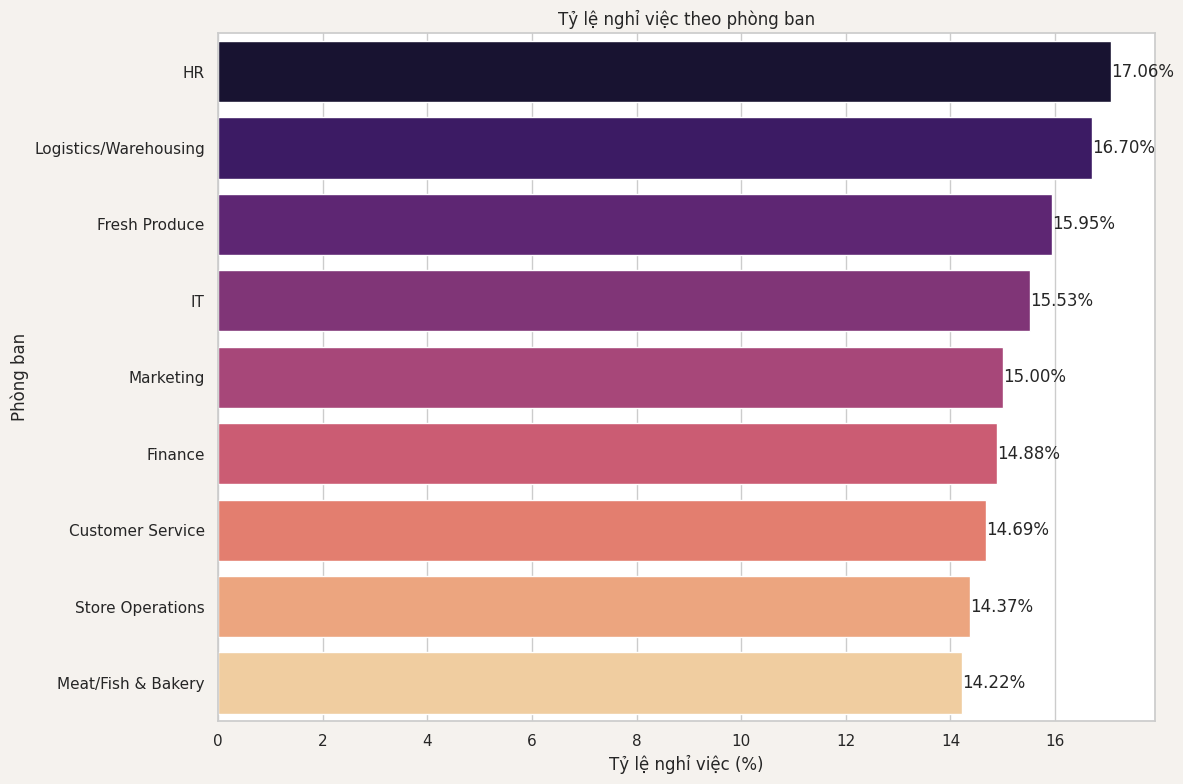

In [ ]:
# Calculate total employees per department
total_employees_per_department = employee_career_summary_full.groupby('Department')['Employee_Id'].nunique()

# Calculate employees who left per department
employees_left_per_department = employee_career_summary_full[employee_career_summary_full['Exit_Date'].notnull()].groupby('Department')['Employee_Id'].nunique()

# Calculate attrition rate per department
attrition_rate_per_department = (employees_left_per_department / total_employees_per_department * 100).fillna(0).reset_index()
attrition_rate_per_department.columns = ['Department', 'Attrition_Rate']

#plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Attrition_Rate', y='Department', data=attrition_rate_per_department.sort_values(by='Attrition_Rate', ascending=False), palette='magma')
plt.title('Tỷ lệ nghỉ việc theo phòng ban')
plt.xlabel('Tỷ lệ nghỉ việc (%)')
plt.ylabel('Phòng ban')

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

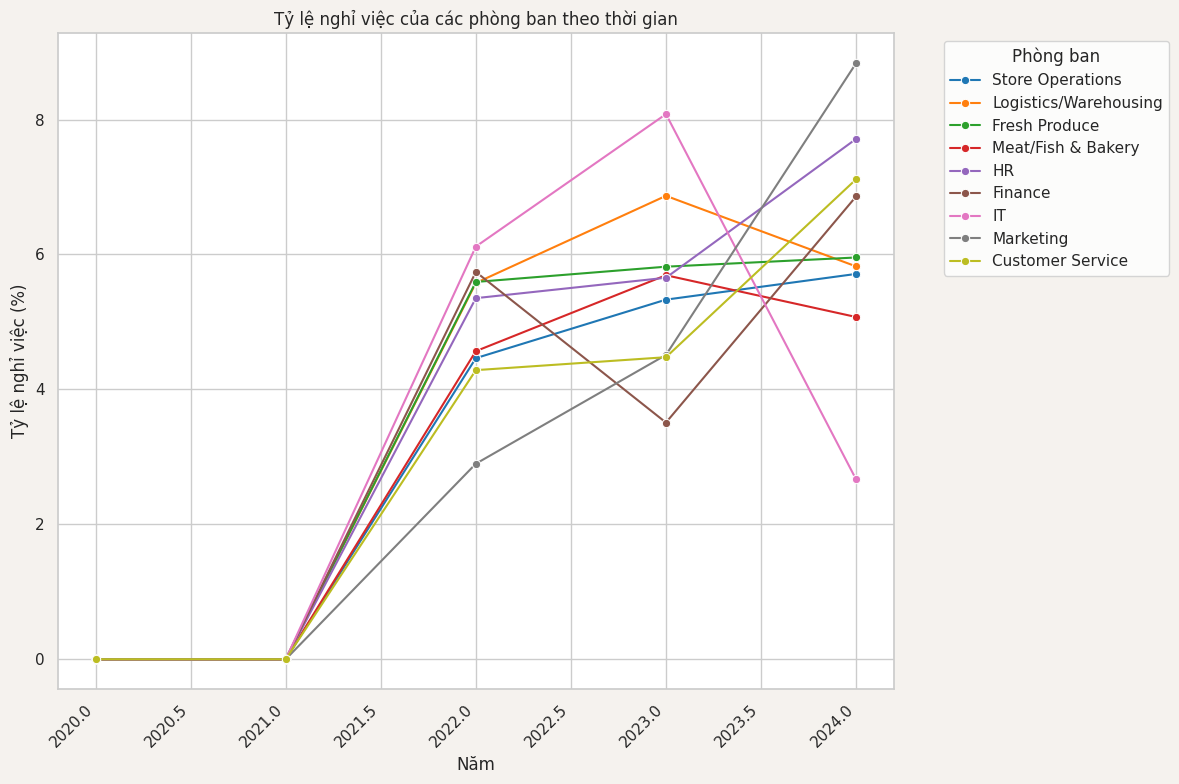

In [ ]:

# Modified to analyze data from 2020 to 2024
all_years = range(2020, 2024 + 1)

attrition_by_department_year = []

for year in all_years:
    for department in df_2024['Department'].unique():
        df_dept = df_2024[df_2024['Department'] == department]

        # Number of employees who exited in the current year for the current department
        exits_in_year_dept = df_dept[df_dept['Exit_Date'].dt.year == year].shape[0]

        # Headcount at the start of the year for the current department
        start_of_year = pd.Timestamp(f'{year}-01-01')
        end_of_year = pd.Timestamp(f'{year}-12-31')

        headcount_start_of_year_dept = df_dept[
            (df_dept['Hire_Date'] <= start_of_year) &
            ((df_dept['Exit_Date'].isnull()) | (df_dept['Exit_Date'] > start_of_year))
        ].shape[0]

        # Headcount at the end of the year for the current department
        headcount_end_of_year_dept = df_dept[
            (df_dept['Hire_Date'] <= end_of_year) &
            ((df_dept['Exit_Date'].isnull()) | (df_dept['Exit_Date'] > end_of_year))
        ].shape[0]

        average_headcount_during_year_dept = (headcount_start_of_year_dept + headcount_end_of_year_dept) / 2

        attrition_rate_dept = 0
        if average_headcount_during_year_dept > 0:
            attrition_rate_dept = (exits_in_year_dept / average_headcount_during_year_dept) * 100

        attrition_by_department_year.append({
            'Year': year,
            'Department': department,
            'Attrition_Rate': attrition_rate_dept,
            'Exits': exits_in_year_dept,
            'Average_Headcount': average_headcount_during_year_dept
        })

attrition_by_department_year_df = pd.DataFrame(attrition_by_department_year)

# Filter out years/departments where there were no active employees or no data relevant
attrition_by_department_year_df = attrition_by_department_year_df[
    (attrition_by_department_year_df['Average_Headcount'] > 0) |
    (attrition_by_department_year_df['Exits'] > 0)
]

# Plotting the attrition rate by department over time
#plt.figure(figsize=(16, 9))
sns.lineplot(
    data=attrition_by_department_year_df,
    x='Year',
    y='Attrition_Rate',
    hue='Department',
    marker='o',
    palette='tab10'
)
plt.title('Tỷ lệ nghỉ việc của các phòng ban theo thời gian')
plt.xlabel('Năm')
plt.ylabel('Tỷ lệ nghỉ việc (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Phòng ban', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Các phòng ban đều có tỷ lệ nghỉ việc tăng dần theo thời gian, nhưng năm 2023-2024 có sự thay đổi về tỷ lệ nghỉ việc ở các phòng ban đặc biệt là IT đang là dep có tỷ lệ cao nhất đã đột ngột giảm mạnh và ngược lại HR hay Marketing lại có tỷ lệ nghỉ việc tăng gấp đôi.

In [ ]:
attrition_pivot_df = attrition_by_department_year_df[
    attrition_by_department_year_df['Year'].isin([2022, 2023, 2024])
].pivot_table(
    index='Department',
    columns='Year',
    values='Attrition_Rate'
).reset_index()

# Rename columns for clarity
attrition_pivot_df.columns.name = None # Remove the 'Year' column name from the index
attrition_pivot_df = attrition_pivot_df.rename(columns={2022: 'Attrition_Rate_2022', 2023: 'Attrition_Rate_2023', 2024: 'Attrition_Rate_2024'})

display(attrition_pivot_df)

,Department,Attrition_Rate_2022,Attrition_Rate_2023,Attrition_Rate_2024
0,Customer Service,4.285714,4.477612,7.114625
1,Finance,5.741627,3.508772,6.860158
2,Fresh Produce,5.593057,5.819296,5.955604
3,HR,5.352798,5.655527,7.713499
4,IT,6.117647,8.080808,2.666667
5,Logistics/Warehousing,5.577982,6.869633,5.823627
6,Marketing,2.898551,4.511278,8.835341
7,Meat/Fish & Bakery,4.567308,5.692600,5.073431
8,Store Operations,4.463643,5.330813,5.712003


**INSIGHT:**
- Có sự thay đổi về tỷ lệ rời bỏ tại các department qua 3 năm gần đây:
    - Marketing đang ở mức 2.89% năm 2023 đã nhảy vọt lên 8.83% năm 2024.
    - IT giảm tỷ lệ người nghỉ việc từ 6.11% năm 2022 xuống còn 2.66% năm 2024, điều này cũng khá hợp lý khi mức độ hài lòng nhân viên tăng đáng kể.
    - HR là Department có mức hài lòng nhân viên thấp nhất trong khi Store Operation là dep có chỉ số Employee Satisfaction cao nhất thì có mức Attrition Rate dao động quanh 5%.

### **5.3.3 Tương quan chỉ số với khả năng nhân sự rời bỏ**

#### **CẤP ĐỘ PHÒNG BAN**

In [ ]:
# 3. Calculate department-level correlations

correlation_metrics = [
    'Attrition_Tag',
    'Avg_Age',
    'Median_Annual_Salary',
    'Total_Promotions',
    'Total_Salary_Increases',
    'Avg_Performance_Rating',
    'Avg_Training_Hours',
    'Avg_Overtime_Hours',
    'Avg_Absenteeism_Days',
    'Avg_Employee_Satisfaction',
    'Avg_Engagement_Index',
    'Avg_Manager_Evaluation',
    'Avg_Productivity_Index'
]

departmental_employee_correlations = []

for department in employee_career_summary['Department'].unique():
    df_dept_employees = employee_career_summary[employee_career_summary['Department'] == department].copy()

    if len(df_dept_employees) < 2:
        print(f"Not enough data for department {department} to calculate correlations. Skipping.")
        continue

    # Calculate Spearman correlation matrix for the current department's employees
    spearman_corr_matrix_dept = df_dept_employees[correlation_metrics].corr(method='spearman')

    # Extract correlations with Attrition_Tag
    attrition_corr_dept = spearman_corr_matrix_dept['Attrition_Tag'].drop('Attrition_Tag', errors='ignore')

    # Convert to DataFrame and add 'Department' column
    attrition_corr_df = attrition_corr_dept.reset_index()
    attrition_corr_df.columns = ['Metric', 'Correlation_with_Attrition_Tag']
    attrition_corr_df['Department'] = department
    departmental_employee_correlations.append(attrition_corr_df)

# Concatenate all departmental correlation results into a single DataFrame
if departmental_employee_correlations:
    all_departmental_employee_correlations_df = pd.concat(departmental_employee_correlations, ignore_index=True)
    print("Correlations with Attrition_Tag for each Department (Spearman, Employee-Level Aggregation):")
    display(all_departmental_employee_correlations_df.pivot(index='Metric', columns='Department', values='Correlation_with_Attrition_Tag').round(2))
else:
    print("No departmental correlation results to display.")

Correlations with Attrition_Tag for each Department (Spearman, Employee-Level Aggregation):


Department,Customer Service,Finance,Fresh Produce,HR,IT,Logistics/Warehousing,Marketing,Meat/Fish & Bakery,Store Operations
Metric,,,,,,,,,
Avg_Absenteeism_Days,0.02,0.13,0.11,0.23,0.13,0.09,0.03,0.12,0.08
Avg_Age,-0.03,-0.12,-0.03,-0.09,0.02,-0.05,0.06,-0.03,-0.03
Avg_Employee_Satisfaction,0.07,-0.07,-0.16,-0.27,-0.21,-0.08,-0.12,-0.14,-0.13
Avg_Engagement_Index,0.11,-0.06,-0.15,-0.24,-0.13,-0.09,-0.16,-0.13,-0.12
Avg_Manager_Evaluation,0.01,-0.11,-0.16,-0.24,-0.24,-0.14,-0.16,-0.16,-0.15
Avg_Overtime_Hours,-0.27,-0.24,-0.28,-0.30,-0.24,-0.32,-0.26,-0.29,-0.24
Avg_Performance_Rating,-0.00,-0.13,-0.17,-0.24,-0.22,-0.14,-0.15,-0.17,-0.15
Avg_Productivity_Index,-0.00,-0.13,-0.17,-0.25,-0.22,-0.14,-0.15,-0.17,-0.15
Avg_Training_Hours,0.07,-0.03,-0.03,-0.01,-0.03,0.01,-0.04,0.06,-0.00


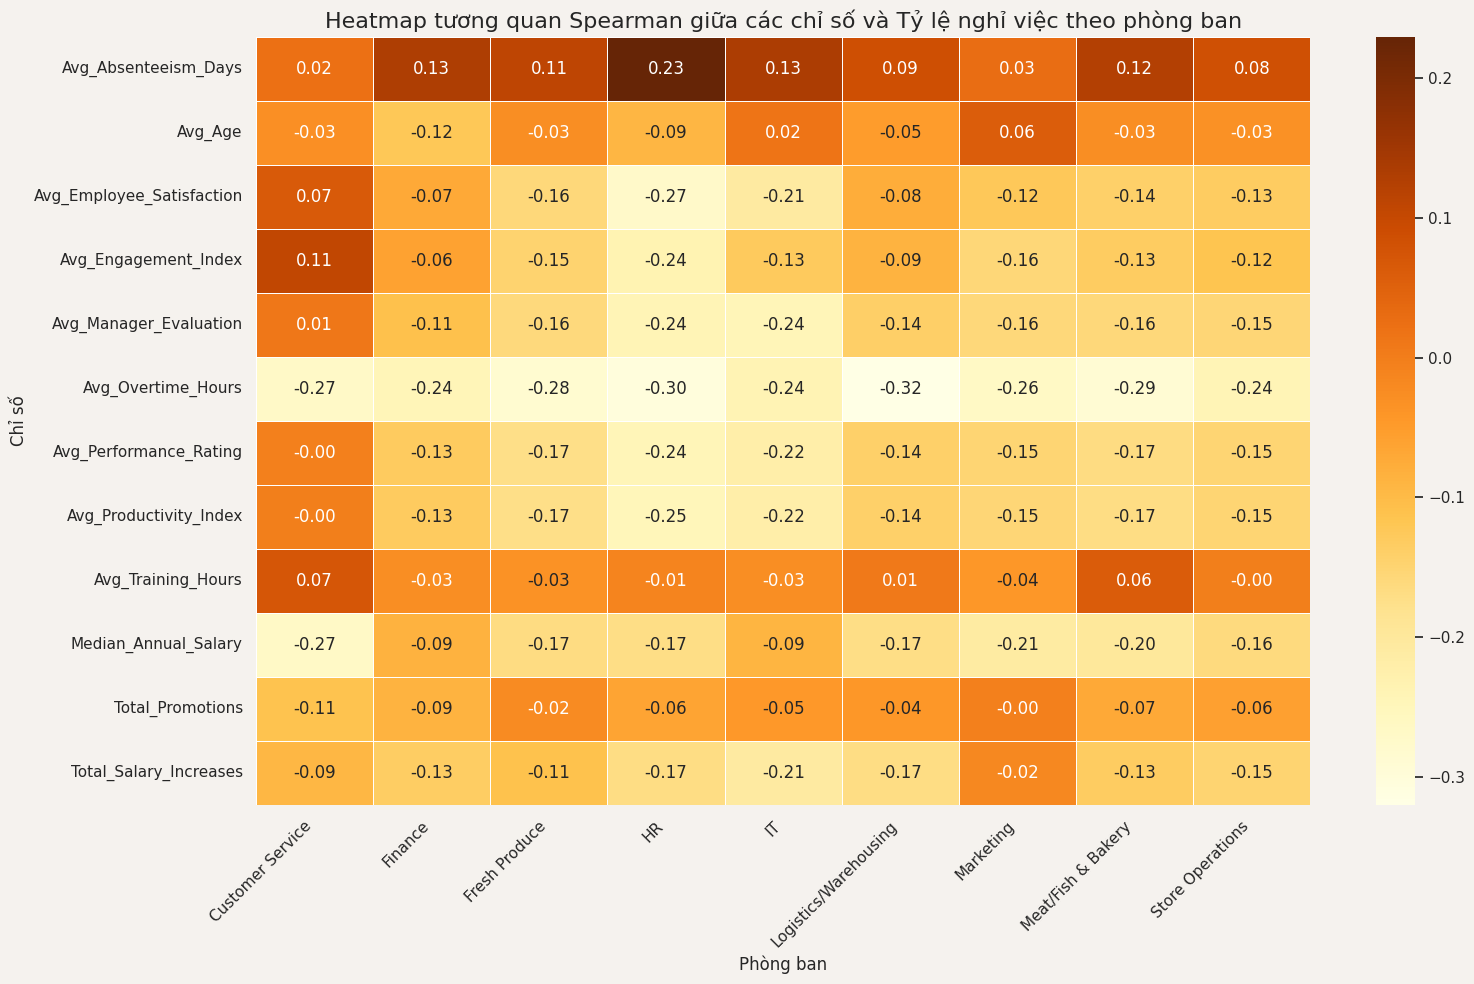

In [ ]:
correlation_pivot = all_departmental_employee_correlations_df.pivot(index='Metric', columns='Department', values='Correlation_with_Attrition_Tag')

plt.figure(figsize=(16, 10))

sns.heatmap(correlation_pivot, annot=True, cmap="YlOrBr", fmt=".2f", linewidths=.5)
plt.title('Heatmap tương quan Spearman giữa các chỉ số và Tỷ lệ nghỉ việc theo phòng ban', fontsize=16)
plt.xlabel('Phòng ban', fontsize=12)
plt.ylabel('Chỉ số', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### **CẤP ĐỘ TOÀN HỆ THỐNG**

In [ ]:
correlation_metrics_overall = [
    'Attrition_Tag',
    'Avg_Age',
    'Median_Annual_Salary',
    'Total_Promotions',
    'Total_Salary_Increases',
    'Avg_Performance_Rating',
    'Avg_Training_Hours',
    'Avg_Overtime_Hours',
    'Avg_Absenteeism_Days',
    'Avg_Employee_Satisfaction',
    'Avg_Engagement_Index',
    'Avg_Manager_Evaluation'
]

# Calculate Spearman correlation matrix for the entire employee career summary
spearman_corr_matrix_overall = employee_career_summary[correlation_metrics_overall].corr(method='spearman')

# Extract correlations with Attrition_Tag and sort them
attrition_correlations_overall = spearman_corr_matrix_overall['Attrition_Tag'].drop('Attrition_Tag', errors='ignore').sort_values(ascending=False)

print("Correlations with Attrition_Tag for the entire system (Spearman, Employee-Level Aggregation):")
display(attrition_correlations_overall)


Correlations with Attrition_Tag for the entire system (Spearman, Employee-Level Aggregation):


,Attrition_Tag
Avg_Absenteeism_Days,0.100468
Avg_Training_Hours,-0.001416
Avg_Age,-0.035659
Total_Promotions,-0.053254
Avg_Engagement_Index,-0.118766
Avg_Employee_Satisfaction,-0.131476
Total_Salary_Increases,-0.144476
Avg_Manager_Evaluation,-0.155399
Avg_Performance_Rating,-0.159107
Median_Annual_Salary,-0.166574


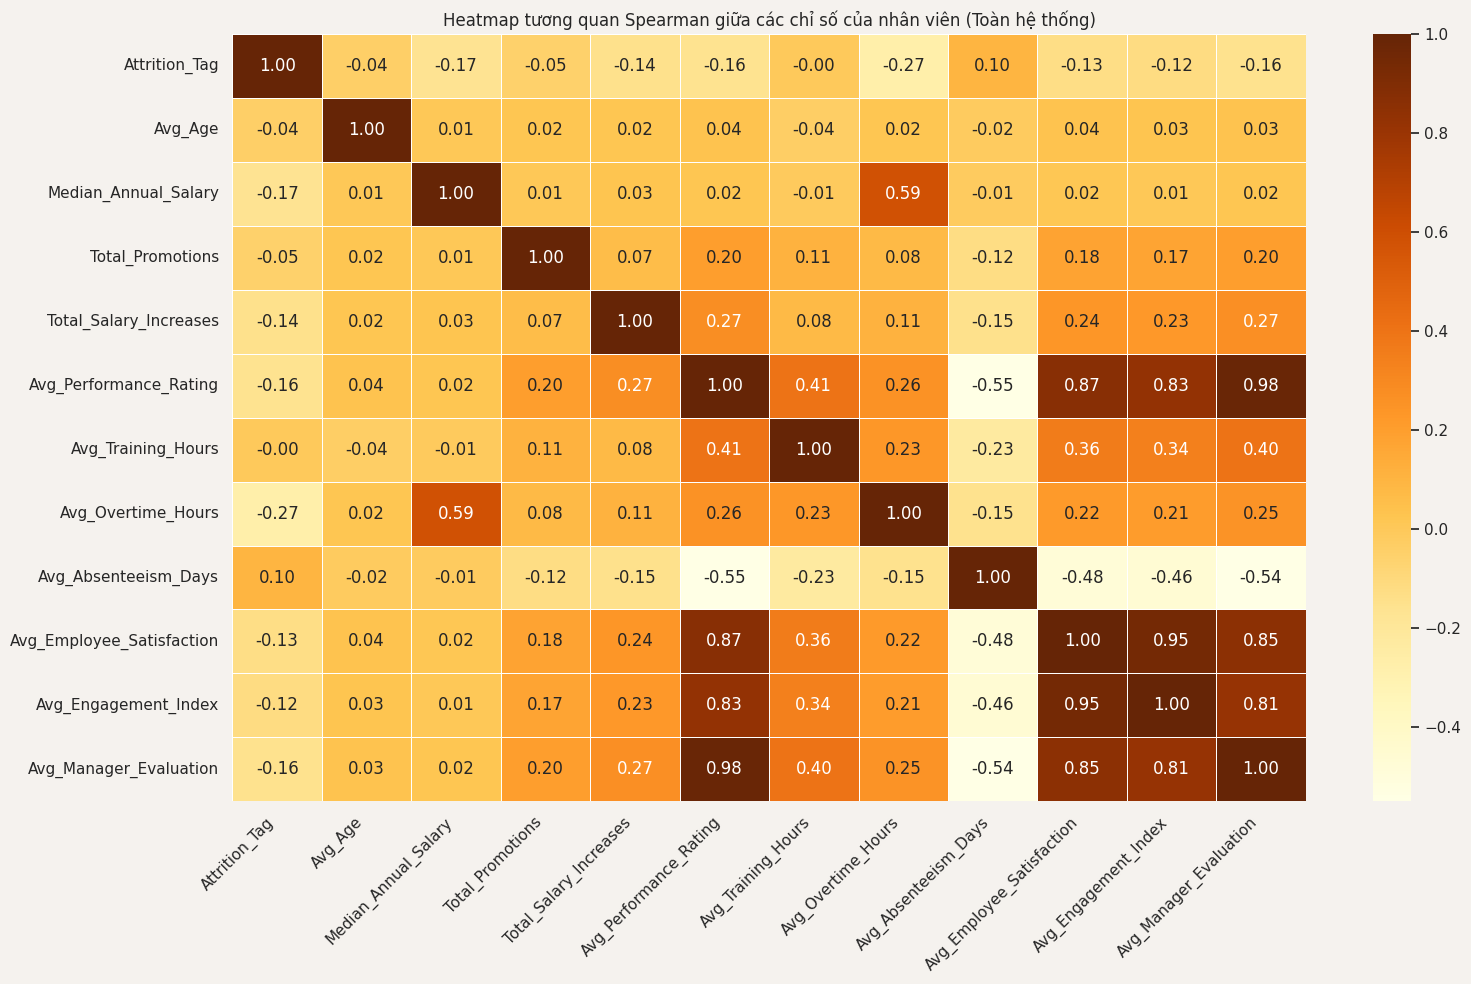

In [ ]:
plt.figure(figsize=(16, 10))
sns.heatmap(spearman_corr_matrix_overall, annot=True, cmap='YlOrBr', fmt=".2f", linewidths=.5)
plt.title('Heatmap tương quan Spearman giữa các chỉ số của nhân viên (Toàn hệ thống)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**INSIGHT**
- Avg_Overtime_Hours có tương quan âm mạnh nhất với Attrition Rate cho thấy những người đang tăng ca nhiều hiện tại lại ít nghỉ việc. Đồng nghĩa, hệ thống đang được vận hành bởi những nhân sự chịu cày cuốc.
- Total Salary Increase và Median Annual Salary đều có tương quan âm với Attrition cho thấy tăng lương thường xuyên có sức nặng giúp nhân sự gắn bó với công ty không thua kém gì mức lương cơ bản. Có lẽ nhân sự rất quan trọng việc được ghi nhận qua công việc.
- Số ngày nghỉ phép là biến tương quan dương duy nhất với nghỉ việc: việc số ngày nghỉ phép tăng lên là một dấu hiệu tiềm ẩn cho thấy nhân sự này sắp nghỉ việc.

Ngoài ra, biểu đồ heatmap cũng cho thấy khi nhân viên hài lòng với công việc, họ làm việc tốt hơn, gắn bó với công ty hơn và đánh giá manager cũng tốt hơn. Hoặc cũng có thể nói, khi họ có lãnh đạo tốt, họ sẽ hài lòng với công ty hơn, gắn bó hơn và làm việc tốt hơn. 4 biến này có mối quan hệ chặt chẽ và cùng nhau phát triển. Việc đào tạo cũng là 1 biến có tương quan dương với 4 biến này, rõ ràng đào tạo đóng vai trò quan trọng trong việc giữ chân nhân sự.
Những nhân viên vắng mặt tăng, performance họ giảm mà họ cũng thể hiện sự sụt giảm trong gắn bó, hay hài lòng với tổ chức.

- Mỗi phòng ban lại có mức độ tương quan giữa các chỉ số và việc nhân viên rời bỏ khác nhau cho thấy đặc điểm nguồn lực tại mỗi phòng ban chuyên môn có đặc thù riêng cần có xây dựng chương trình quản trị nhân sự và phát triển nguồn lực phù hợp tại mỗi nơi.


# **Phần 6: Phân loại nguồn lực**

### **6.1 Chuẩn bị dữ liệu**

- Chỉ sử dụng dữ liệu 6 tháng gần nhất để phân loại nguồn lao động cũng như xây dựng chương trình hành động năm 2025

In [ ]:
df['Year_Month'] = pd.to_datetime(df['Year_Month'])
# Set reference date (latest month in the dataset)
max_date = df['Year_Month'].max()
print(f'Tháng cuối cùng trong dữ liệu: {max_date.strftime("%B %Y")}')

# Define time windows
six_months_ago = max_date - pd.DateOffset(months=6)
three_months_ago = max_date - pd.DateOffset(months=3)
nine_months_ago = max_date - pd.DateOffset(months=9)

print(f'Khoảng phân tích: {six_months_ago.strftime("%Y-%m")} đến {max_date.strftime("%Y-%m")}')
print(f'Phân tích xu hướng: hoạt động tháng {six_months_ago.strftime("%Y-%m")} so với thời gian trước')

# Filter to last 6 months for analysis
df_6m = df[df['Year_Month'] >= six_months_ago].copy()

print(f'Tệp dữ liệu 6 tháng gần nhất: {df_6m.shape}')
print(f'Số lượng nhân sự: {df_6m["Employee_Id"].nunique()}')
print(f'Missing values (%):')
print((df_6m.isnull().sum() / len(df_6m) * 100).sort_values(ascending=False).head(10))

Tháng cuối cùng trong dữ liệu: December 2024
Khoảng phân tích: 2024-06 đến 2024-12
Phân tích xu hướng: hoạt động tháng 2024-06 so với thời gian trước
Tệp dữ liệu 6 tháng gần nhất: (42952, 38)
Số lượng nhân sự: 6228
Missing values (%):
Exit_Date          97.930248
Manager_Name        0.081486
Manager_Status      0.081486
Manager_Id          0.081486
Full_Name           0.000000
Employee_Id         0.000000
Hire_Date           0.000000
Education_Level     0.000000
Age                 0.000000
Department          0.000000
dtype: float64


### **6.2 Đánh giá hiệu quả lao động**

In [ ]:
df_promo = df_6m.groupby('Employee_Id').agg(
    Avg_Performance=('Performance_Rating', 'mean'),
    Avg_Manager_Eval=('Manager_Evaluation', 'mean'),
    Avg_Training=('Training_Hours', 'mean'),
    Total_Absenteeism=('Absenteeism_Days', 'sum'),
    Hire_Date=('Hire_Date', 'first'),
    Job_Level=('Job_Level', 'first'),
    Full_Name=('Full_Name', 'first'),
    Department=('Department', 'first'),
    Job_Role=('Job_Role', 'first'),
    Base_Salary_Annual=('Base_Salary_Annual', 'first')
).reset_index()

# Convert Hire_Date to datetime objects to ensure compatibility with max_date (Timestamp)
df_promo['Hire_Date'] = pd.to_datetime(df_promo['Hire_Date'])

# Compute tenure in months more precisely using month periods
df_promo['Tenure_Months'] = (max_date.to_period('M') - df_promo['Hire_Date'].dt.to_period('M')).apply(lambda x: x.n)

# Normalize scores to 0-100 scale
df_promo['Performance_Score'] = (df_promo['Avg_Performance'] / 5) * 100
df_promo['Manager_Score'] = (df_promo['Avg_Manager_Eval'] / 5) * 100
df_promo['Training_Score'] = np.minimum(df_promo['Avg_Training'] * 5, 100)

print(f'Promotion scorecard prepared: {df_promo.shape}')
print(f'\nScore distributions:')
print(df_promo[['Performance_Score', 'Manager_Score', 'Training_Score']].describe().round(2))

Promotion scorecard prepared: (6228, 15)

Score distributions:
       Performance_Score  Manager_Score  Training_Score
count            6228.00        6228.00         6228.00
mean               74.88          74.86           13.39
std                 7.02           7.41            7.00
min                50.31          48.50            0.00
25%                69.63          69.43            8.57
50%                74.97          74.86           10.71
75%                80.23          80.29           15.00
max                94.63          95.71           40.71


Mỗi vị trí công việc sẽ có KPI khác nhau, so sánh KPI của mỗi nhân viên với KPI trung bình của vị trí để làm cơ sở đánh giá mức độ hoành thành KPI của họ.

In [ ]:
df_kpi_avg = df_6m.groupby('Employee_Id').agg(
    Avg_Kpi1=('Kpi_1_Value', 'mean'),
    Avg_Kpi2=('Kpi_2_Value', 'mean'),
    Avg_Kpi3=('Kpi_3_Value', 'mean'),
    Avg_Productivity=('Productivity_Index', 'mean'),
    Job_Role=('Job_Role', 'first')
).reset_index()

# Tính toán role-level benchmarks
df_role_bench = df_kpi_avg.groupby('Job_Role').agg(
    Role_Avg_Kpi1=('Avg_Kpi1', 'mean'),
    Role_Avg_Kpi2=('Avg_Kpi2', 'mean'),
    Role_Avg_Kpi3=('Avg_Kpi3', 'mean'),
    Role_Avg_Productivity=('Avg_Productivity', 'mean')
).reset_index()

# Ghép 2 bảng
df_kpi_final = pd.merge(df_kpi_avg, df_role_bench, on='Job_Role', how='left')

# Avoid division by zero
df_kpi_final['Kpi1_Ratio'] = np.where(
    df_kpi_final['Role_Avg_Kpi1'] > 0,
    (df_kpi_final['Avg_Kpi1'] / df_kpi_final['Role_Avg_Kpi1']) * 100,
    50
)
df_kpi_final['Kpi2_Ratio'] = np.where(
    df_kpi_final['Role_Avg_Kpi2'] > 0,
    (df_kpi_final['Avg_Kpi2'] / df_kpi_final['Role_Avg_Kpi2']) * 100,
    50
)
df_kpi_final['Kpi3_Ratio'] = np.where(
    df_kpi_final['Role_Avg_Kpi3'] > 0,
    (df_kpi_final['Avg_Kpi3'] / df_kpi_final['Role_Avg_Kpi3']) * 100,
    50
)

In [ ]:
# Loại bỏ những giá trị outliers

def clip_series_by_iqr(series):
    """
    Nhận vào 1 cột (Pandas Series), tính toán IQR và trả về Series đã được clip.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + (1.5 * iqr)

    # In thông báo để theo dõi tên cột đang xử lý
    print(f"Xử lý cột {series.name}: Ngưỡng trần = {upper_bound:.2f}")

    return series.clip(0, upper_bound)


df_kpi_final['Kpi1_Score'] = clip_series_by_iqr(df_kpi_final['Kpi1_Ratio'])
df_kpi_final['Kpi2_Score'] = clip_series_by_iqr(df_kpi_final['Kpi2_Ratio'])
df_kpi_final['Kpi3_Score'] = clip_series_by_iqr(df_kpi_final['Kpi3_Ratio'])


# Composite KPI score
df_kpi_final['KPI_Index_Score'] = df_kpi_final[['Kpi1_Score', 'Kpi2_Score', 'Kpi3_Score']].mean(axis=1)
df_kpi_final['Productivity_Score'] = (df_kpi_final['Avg_Productivity'] / df_kpi_final['Role_Avg_Productivity']).clip(0, 120) * 100

print(f'\nKPI benchmarking completed: {df_kpi_final.shape}')
print(f'\nKPI Score (normalized to 100 = role average):')
print(df_kpi_final[['KPI_Index_Score', 'Productivity_Score']].describe().round(2))

Xử lý cột Kpi1_Ratio: Ngưỡng trần = 268.43
Xử lý cột Kpi2_Ratio: Ngưỡng trần = 212.49
Xử lý cột Kpi3_Ratio: Ngưỡng trần = 243.94

KPI benchmarking completed: (6228, 18)

KPI Score (normalized to 100 = role average):
       KPI_Index_Score  Productivity_Score
count          6228.00             6228.00
mean             88.61              100.00
std              29.63               12.52
min              46.96               56.88
25%              63.07               90.89
50%              85.55              100.08
75%             101.36              109.28
max             183.43              137.83


In [ ]:
df_promo = pd.merge(
    df_promo,
    df_kpi_final[['Employee_Id', 'KPI_Index_Score', 'Productivity_Score']],
    on='Employee_Id',
    how='left'
)

df_promo['KPI_Index_Score'] = df_promo['KPI_Index_Score'].fillna(100)
df_promo['Productivity_Score'] = df_promo['Productivity_Score'].fillna(100)

print('KPI scores merged into promotion scorecard')

KPI scores merged into promotion scorecard


**Tính toán chỉ số thăng tiến**



---


**Tỷ lệ:**

- Performance Rating: 20% (manager evaluation of capability)
- KPI Achievement: 25% (objective, role-benchmarked)
- Productivity Index: 25% (efficiency and output)
- Manager Evaluation: 20% (readiness judgment)
- Training Investment: 10% (development commitment)

**Điều kiện:** Thâm niên >= 2 năm + số ngày nghỉ trong 6 tháng gần nhất không quá 9 ngày. (thường nhân sự nghỉ 1-2 ngày/tháng là bình thường )


---




In [ ]:
# Composite Promotion Score (0-100)
df_promo['Promotion_Score'] = (
    df_promo['Performance_Score'] * 0.20 +
    df_promo['KPI_Index_Score'] * 0.25 +
    df_promo['Productivity_Score'] * 0.25 +
    df_promo['Manager_Score'] * 0.20 +
    df_promo['Training_Score'] * 0.10
)

# Eligibility gate
cond_eligible = (df_promo['Tenure_Months'] >= 24) & (df_promo['Total_Absenteeism'] <= 9)
df_promo['Eligible_For_Promotion'] = cond_eligible

# Promotion threshold
promo_threshold = 85
df_promo['Ready_For_Promotion'] = (df_promo['Eligible_For_Promotion']) & (df_promo['Promotion_Score'] >= promo_threshold)

print(f'Bảng chỉ số thăng tiến')
print(f'\nNhân sự cần được đánh giá thăng tiến:')
print(f'  SL nhân sự đủ điều kiện (thâm tiên + chuyên cần): {cond_eligible.sum()}')
print(f'  Nhân sự xứng đáng (đủ điều kiện và điểm thăng tiến >= {promo_threshold}): {df_promo["Ready_For_Promotion"].sum()}')
print(f'\nPromotion Score distribution (có thể dùng để set promotion threshold):')
print(df_promo['Promotion_Score'].describe().round(2))

Bảng chỉ số thăng tiến

Nhân sự cần được đánh giá thăng tiến:
  SL nhân sự đủ điều kiện (thâm tiên + chuyên cần): 5997
  Nhân sự xứng đáng (đủ điều kiện và điểm thăng tiến >= 85): 1350

Promotion Score distribution (có thể dùng để set promotion threshold):
count    6228.00
mean       78.44
std         9.28
min        51.04
25%        71.90
50%        77.81
75%        83.99
max       113.53
Name: Promotion_Score, dtype: float64


### **6.3 Đánh giá nguy cơ nghỉ việc**



---


**6 dấu hiệu**
  - Absenteeism spike (20%): Tỷ lệ vắng mặt tăng gấp ≥1.5x
  - Giảm sự hài lòng (15%): Chỉ số hài lòng giảm 1.0 so với trung bình kỳ trước
  - Giảm gắn kết (15%): Chỉ số gắn kết ≥1 point thấp hơn
  - Lộ trình thăng tiến kém (20%): Không được promote hay tăng lương trong 12 tháng gần nhất
  - Làm việc quá độ (10%): tổng thời gian làm OT cao hơn 90% cùng vị trí + top nhân sự (promotion score ≥85)
  - Underpaid (20%): Top nhân sự (score ≥85) có mức lương trung bình thấp hon 80% trung bình vị trí.

Max Flight Risk Score: 100 (all 6 signals triggered)

In [ ]:
# Split into recent and past cohorts
df_recent = df[df['Year_Month'] >= six_months_ago].copy()
df_past = df[
    (df['Year_Month'] >= nine_months_ago) &
    (df['Year_Month'] < six_months_ago)
].copy()

# Aggregate metrics by period
grp_recent = df_recent.groupby('Employee_Id')[[
    'Absenteeism_Days', 'Employee_Satisfaction', 'Engagement_Index'
]].agg(['mean', 'std']).reset_index()
grp_recent.columns = ['Employee_Id', 'Abs_mean_recent', 'Abs_std_recent', 'Sat_mean_recent', 'Sat_std_recent', 'Eng_mean_recent', 'Eng_std_recent']

grp_past = df_past.groupby('Employee_Id')[[
    'Absenteeism_Days', 'Employee_Satisfaction', 'Engagement_Index'
]].mean().reset_index()
grp_past.columns = ['Employee_Id', 'Abs_mean_past', 'Sat_mean_past', 'Eng_mean_past']

# Merge trends
df_trend = pd.merge(grp_recent, grp_past, on='Employee_Id', how='inner')

print(f'Trend analysis: {df_trend.shape[0]} employees')

Trend analysis: 6228 employees


In [ ]:
# SIGNAL 1: Nghỉ phép nhiều hơn
df_trend['Absenteeism_Ratio'] = np.where(
    df_trend['Abs_mean_past'] > 0,
    df_trend['Abs_mean_recent'] / df_trend['Abs_mean_past'],
    1.0
)
df_trend['Risk_Absenteeism'] = np.where(df_trend['Absenteeism_Ratio'] >= 1.5, 1, 0)

# SIGNAL 2: Sụt giảm sự hài lòng
df_trend['Satisfaction_Drop'] = df_trend['Sat_mean_past'] - df_trend['Sat_mean_recent']
df_trend['Risk_Satisfaction'] = np.where(df_trend['Satisfaction_Drop'] >= 1.0, 1, 0)

# SIGNAL 3: Kém kết nối và gắn kết
df_trend['Engagement_Drop'] = df_trend['Eng_mean_past'] - df_trend['Eng_mean_recent']
df_trend['Risk_Engagement'] = np.where(df_trend['Engagement_Drop'] >= 1.0, 1, 0)

# SIGNAL 4: Không được tăng lương hay thăng chức trong 24 tháng
# Find last month with Salary_Increase_Flag or Promotion_Flag = True
df_all_months = df.copy()
df_last_reward = df_all_months[
    (df_all_months['Salary_Increase_Flag'] == True) |
    (df_all_months['Promotion_Flag'] == True)
].groupby('Employee_Id')['Year_Month'].max().reset_index()
df_last_reward.columns = ['Employee_Id', 'Last_Reward_Month']

# Merge back and calculate months without reward
df_trend = pd.merge(
    df_trend.drop(columns=[c for c in df_trend.columns if c.startswith('Last_Reward_Month')], errors='ignore'),
    df_last_reward,
    on='Employee_Id',
    how='left'
)
df_trend['Last_Reward_Month'] = df_trend['Last_Reward_Month'].fillna(pd.to_datetime('2022-01-01'))
df_trend['Months_Without_Reward'] = (
    (max_date - df_trend['Last_Reward_Month']).dt.days / 30.4375
).astype(int)
df_trend['Risk_Stagnation'] = np.where(df_trend['Months_Without_Reward'] >= 18, 1, 0)

# SIGNAL 5: Kiệt sức vì công việc
df_ot = df_6m.groupby(['Employee_Id', 'Job_Role']).agg({
    'Overtime_Hours': 'mean'
}).reset_index()
df_ot.columns = ['Employee_Id', 'Job_Role_ot', 'Avg_Overtime']

df_ot_bench = df_6m.groupby('Job_Role')['Overtime_Hours'].quantile(0.90).reset_index()
df_ot_bench.columns = ['Job_Role', 'Role_OT_P90']

df_ot = pd.merge(df_ot, df_ot_bench, left_on='Job_Role_ot', right_on='Job_Role', how='left')
df_ot = pd.merge(df_ot, df_promo[['Employee_Id', 'Promotion_Score']], on='Employee_Id', how='left')
df_ot['Is_Burnout'] = (
    (df_ot['Avg_Overtime'] >= df_ot['Role_OT_P90']) &
    (df_ot['Promotion_Score'] >= 85)
)
df_ot['Risk_Burnout'] = np.where(df_ot['Is_Burnout'], 1, 0)

df_trend = pd.merge(
    df_trend.drop(columns=[c for c in df_trend.columns if c.startswith('Risk_Burnout')], errors='ignore'),
    df_ot[['Employee_Id', 'Risk_Burnout']],
    on='Employee_Id',
    how='left'
)
df_trend['Risk_Burnout'] = df_trend['Risk_Burnout'].fillna(0).astype(int)

# SIGNAL 6: Underpaid (Salary < 80% of role average)
df_role_salary = df_employees.groupby('Job_Role').agg({
    'Base_Salary_Annual': 'mean'
}).reset_index()
df_role_salary.columns = ['Job_Role', 'Role_Avg_Salary']

df_salary = df_promo[['Employee_Id', 'Base_Salary_Annual', 'Job_Role', 'Promotion_Score']].copy()
df_salary = pd.merge(df_salary, df_role_salary, on='Job_Role', how='left')
df_salary['Salary_Ratio'] = (df_salary['Base_Salary_Annual'] / df_salary['Role_Avg_Salary']) * 100
df_salary['Is_Underpaid'] = (
    (df_salary['Promotion_Score'] >= 85) &
    (df_salary['Salary_Ratio'] < 80)
)
df_salary['Risk_Underpaid'] = np.where(df_salary['Is_Underpaid'], 1, 0)

df_trend = pd.merge(df_trend, df_salary[['Employee_Id', 'Risk_Underpaid', 'Salary_Ratio']], on='Employee_Id', how='left')
if 'Risk_Underpaid_y' in df_trend.columns:
    df_trend['Risk_Underpaid'] = df_trend['Risk_Underpaid_y'].fillna(
        df_trend.get('Risk_Underpaid_x', 0)
    ).astype(int)
    df_trend.drop(
        columns=[c for c in ['Risk_Underpaid_x', 'Risk_Underpaid_y'] if c in df_trend.columns],
        inplace=True
    )
else:
    df_trend['Risk_Underpaid'] = df_trend['Risk_Underpaid'].fillna(0).astype(int)

if 'Salary_Ratio_y' in df_trend.columns:
    df_trend['Salary_Ratio'] = df_trend['Salary_Ratio_y'].fillna(
        df_trend.get('Salary_Ratio_x', np.nan)
    )
    df_trend.drop(
        columns=[c for c in ['Salary_Ratio_x', 'Salary_Ratio_y'] if c in df_trend.columns],
        inplace=True
    )
df_trend['Salary_Ratio'] = df_trend['Salary_Ratio'].fillna(100)

# COMPOSITE: Flight Risk Index (6 signals, max = 100)
df_trend['Flight_Risk_Index'] = (
    df_trend['Risk_Absenteeism'] * 20 +
    df_trend['Risk_Satisfaction'] * 15 +
    df_trend['Risk_Engagement'] * 15+
    df_trend['Risk_Stagnation'] * 20 +
    df_trend['Risk_Burnout'] * 10 +
    df_trend['Risk_Underpaid'] * 20
)

print(f'Flight Risk analysis (6 signals):')
print(f'  Stagnation (no reward 24+ months): {(df_trend["Risk_Stagnation"] > 0).sum()}')
print(f'  Burnout (high OT + top performer): {(df_trend["Risk_Burnout"] > 0).sum()}')
print(f'  Underpaid (< 90% role avg + top performer): {(df_trend["Risk_Underpaid"] > 0).sum()}')
print(f'  High risk (score >= 60): {(df_trend["Flight_Risk_Index"] >= 60).sum()}')
print(f'\nFlight Risk Score distribution:')
print(df_trend['Flight_Risk_Index'].describe().round(2))

Flight Risk analysis (6 signals):
  Stagnation (no reward 24+ months): 4692
  Burnout (high OT + top performer): 165
  Underpaid (< 90% role avg + top performer): 368
  High risk (score >= 60): 218

Flight Risk Score distribution:
count    6228.00
mean       26.46
std        16.46
min         0.00
25%        20.00
50%        20.00
75%        40.00
max        90.00
Name: Flight_Risk_Index, dtype: float64


### **6.4 Ma trận phân loại nhân sự**

In [ ]:
# Merge flight risk and last reward month into promotion scorecard
df_final = pd.merge(
    df_promo,
    df_trend[['Employee_Id', 'Flight_Risk_Index', 'Last_Reward_Month']],
    on='Employee_Id',
    how='left'
)

df_final['Flight_Risk_Index'] = df_final['Flight_Risk_Index'].fillna(0)

# Define thresholds
high_talent_threshold = 90
high_risk_threshold = 60 # User-defined as >60 for High FRI, <=60 for Low/Medium FRI

# Helper function to categorize Promotion Score
def get_promotion_score_category_str(score):
    if score >= high_talent_threshold: # This is >= 85
        return 'High PS'
    elif score >= 72: # User defined '72 to <85'
        return 'Medium PS'
    else: # User defined '<72'
        return 'Low PS'

# Helper function to categorize Flight Risk Index
def get_flight_risk_category_str(risk_index):
    if risk_index >= high_risk_threshold: # This is >= 60
        return 'High FRI'
    else: # User defined '<= 20' and '20 < Index < 60' now grouped as Low/Medium FRI
        return 'Low/Medium FRI'

# Modified Classification function for more detailed segments based on user's new groups
def classify_talent(row):
    promotion_score = row['Promotion_Score']
    flight_risk_index = row['Flight_Risk_Index']
    eligible_for_promotion = row['Eligible_For_Promotion'] # Still use for other segments if needed

    is_high_ps = (promotion_score >= high_talent_threshold)
    is_medium_ps = (promotion_score >= 72) and (promotion_score < high_talent_threshold)
    is_low_ps = (promotion_score < 72)

    is_high_fri = (flight_risk_index >= high_risk_threshold)
    is_low_medium_fri = (flight_risk_index < high_risk_threshold) # This combines the user's Low and Medium Risk into one for Group A and B

    segment_name = ""

    # Nhóm A (The Stars): High PS + Low/Medium FRI
    if is_high_ps and is_low_medium_fri:
        # Check if Last_Reward_Month is within the last 3 months
        if row['Last_Reward_Month'] >= three_months_ago:
            segment_name = 'Nhóm A (Action Soon!)'
        else:
            segment_name = 'Nhóm A (The Stars)'
    # Nhóm B (The Core/Stable): Medium PS + Low/Medium FRI
    elif is_medium_ps and is_low_medium_fri:
        segment_name = 'Nhóm B (The Core)'
    # Nhóm C (The Risks/Flight Risk): High PS + High FRI
    elif is_high_ps and is_high_fri:
        segment_name = 'Nhóm C (The Risks)'
    # Nhóm D (The Bottom/Alert): Low PS + High FRI
    elif is_low_ps and is_high_fri:
        segment_name = 'Nhóm F (The Alert)'
    elif is_low_ps and is_low_medium_fri:
        segment_name = 'Nhóm D (Need to Train)'
    elif is_medium_ps and is_high_fri:
        segment_name = 'Nhóm E (Need to Pursue)'
    # Fallback for any other unexpected combinations (should ideally not be reached with comprehensive definitions)
    else:
        ps_cat_str = get_promotion_score_category_str(promotion_score)
        fri_cat_str = get_flight_risk_category_str(flight_risk_index)
        eligible_str = "Eligible" if eligible_for_promotion else "Not Eligible"
        segment_name = f'Nhóm Khác (Unexpected: {eligible_str}, {ps_cat_str}, {fri_cat_str})'

    return segment_name

df_final['Talent_Segment'] = df_final.apply(classify_talent, axis=1)

# Segment summary
segment_summary = df_final['Talent_Segment'].value_counts().sort_index()

print('MA TRẬN PHÂN LOẠI NHÂN SỰ CHI TIẾT (2×2)')
print('---------------------------------')
for segment, count in segment_summary.items():
    pct = count / len(df_final) * 100
    print(f'{segment:50s}: {count:>5} ({pct:>5.1f}%)')

In [ ]:
import plotly.express as px

fig = px.scatter(df_final,
                 x='Promotion_Score',
                 y='Flight_Risk_Index',
                 color='Talent_Segment',
                 hover_name='Full_Name',
                 hover_data=['Department', 'Job_Role', 'Job_Level', 'Base_Salary_Annual', 'Talent_Segment'],
                 title='Biểu đồ phân tán nhân sự theo điểm thăng tiến và chỉ số rủi ro nghỉ việc',
                 labels={
                     'Promotion_Score': 'Điểm Thăng Tiến',
                     'Flight_Risk_Index': 'Chỉ Số Rủi Ro Nghỉ Việc',
                     'Talent_Segment': 'Phân Loại Tài Năng'
                 })

fig.update_layout(
    xaxis_title='Promotion Score (Higher is Better)',
    yaxis_title='Flight Risk Index (Lower is Better)',
    legend_title='Talent Segment'
)
fig.show()

In [ ]:
df_final_grouped = df_final.copy()
df_final_grouped['Talent_Segment_Grouped'] = df_final_grouped['Talent_Segment'].replace({
    'Nhóm A (Action Soon!)': 'Nhóm A (Stars)',
    'Nhóm A (The Stars)': 'Nhóm A (Stars)'
})


talent_segments_order = [
    'Nhóm A (Stars)',
    'Nhóm B (The Core)',
    'Nhóm C (The Risks)',
    'Nhóm D (Need to Train)',
    'Nhóm E (Need to Pursue)',
    'Nhóm F (The Alert)'
]

# Filter out any segments that might not be in the list, though with current data it should be fine
df_final_grouped = df_final_grouped[df_final_grouped['Talent_Segment_Grouped'].isin(talent_segments_order)]

# Ensure the order for plotting
df_final_grouped['Talent_Segment_Grouped'] = pd.Categorical(df_final_grouped['Talent_Segment_Grouped'], categories=talent_segments_order, ordered=True)


fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 20), sharex=True, sharey=False)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, segment in enumerate(talent_segments_order):
    subset = df_final_grouped[df_final_grouped['Talent_Segment_Grouped'] == segment]
    sns.histplot(data=subset, x='Promotion_Score', kde=True, ax=axes[i], color='teal') # Use a consistent color
    axes[i].set_title(f'Phân phối điểm thăng tiến: {segment}', fontsize=14)
    axes[i].set_xlabel('Điểm thăng tiến', fontsize=12)
    axes[i].set_ylabel('Tần suất', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Phân phối điểm thăng tiến theo Phân khúc tài năng (Histograms)', y=1.02, fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

In [ ]:
df_wave = df_final_grouped[df_final_grouped['Talent_Segment']=='Nhóm A (Action Soon!)'].copy()
df_wave = df_wave[['Full_Name','Employee_Id', 'Department', 'Job_Role']].reset_index(drop=True)
print("Danh sách nhân sự được tăng lương hoặc tăng bậc kỳ tới:")
df_wave
#

# **Phần 7: Recommendations**

## **7.1 Chiến lược quản lý nhân sự**

### **7.1.1 CẤP TOÀN CÔNG TY**

***Dành cho Ban Giám Đốc và Khối Nhân Sự Tổng Lãnh Đạo.***

1. Quản trị rủi ro nhóm nhân sự "Chịu cày" (OT)
  - Thực trạng: Biến Avg_Overtime_Hours có tương quan âm mạnh nhất (-0.271). Những người tăng ca nhiều hiện tại lại ít nghỉ việc nhất.
  - Hành động: Đây là nhóm đang gánh vác vận hành nhưng có rủi ro kiệt sức tiềm ẩn. Cần tổ chức các cuộc khảo sát sức khỏe tinh thần ẩn danh và thiết lập hạn mức OT trần để tránh việc họ đột ngột nghỉ việc hàng loạt khi quá sức chịu đựng. Ngoài ra có thể tạo thêm các chương trình hỗ trợ cho các nhân sự OT như phục vụ đồ ăn vặt/nước giải khát vào những buổi OT kéo dài.
2. Duy trì hệ thống thu nhập
  - Thực trạng: Tần suất tăng lương (Total_Salary_Increases: -0.16) có sức nặng giữ chân nhân sự không thua kém mức lương cố định (Median_Annual_Salary: -0.17) và Overtime_Hours có tương quan dương rất mạnh với Median_Annual_Salary cho thấy cty đang có cơ chế chi trả OT sòng phẳng và xứng đáng
  - Hành động: Bên cạnh đợt tăng lương lớn duy nhất vào cuối năm, duy trì các kỳ đánh giá hiệu suất ngắn hạn (ví dụ: 6 tháng một lần). Nhân viên cần nhìn thấy thu nhập của họ được tăng liên tục theo đóng góp sẽ tạo động lực cho họ gắn bó hơn.
3. Xây dựng "Hệ thống cảnh báo sớm" qua số ngày vắng mặt
  - Thực trạng: Biến Avg_Absenteeism_Days có tương quan dương (0.100) trên toàn hệ thống. và một nhân sự có ngày nghỉ tăng, hiệu quả công việc họ cũng có xu hướng giảm mà họ cũng thể hiện sự sụt giảm trong gắn bó, hay hài lòng với tổ chức.
  - Hành động: Cài đặt bộ lọc tự động trên hệ thống chấm công. Nếu một nhân sự có số ngày nghỉ lặt vặt tăng đột biến >20\% so với trung bình các tháng trước, hệ thống sẽ gắn "Cờ vàng" để HR và Quản lý trực tiếp chủ động trao đổi và chấn chỉnh hoặc đưa ra giải pháp phù hợp trước khi họ nộp đơn nghỉ việc.

4. Chuẩn hóa bộ tiêu chuẩn Quản lý cấp trung
  - Thực trạng: Vì năng lực của Quản lý trực tiếp (Avg_Manager_Evaluation) liên đới trực tiếp đến Hiệu suất (0.98) và Sự hài lòng (0.85)
  - Hành động: công ty cần đầu tư ngân sách vào các chương trình đào tạo "Năng lực quản trị con người" cho các Trưởng phòng/Trưởng nhóm/Store Manager thay vì chỉ chú trọng vào kỹ năng chuyên môn.
  
### **7.1.2 CHƯƠNG TRÌNH CHO TỪNG PHÒNG BAN**

Dành cho các Giám đốc bộ phận (Head of Department) phối hợp cùng HR BP.

**1. Khối Dịch vụ & Kinh doanh (Customer Service & Marketing)**
  - Đặc trưng dữ liệu: Cực kỳ nhạy cảm với thu nhập (Median_Annual_Salary tại CS là -0.32, Marketing là -0.23). OverTime Hours tương quan âm mạnh.
  - Bất thường: Khối Customer Service có hiện tượng nghịch lý khi chỉ số gắn kết mang dấu dương nhẹ (0.11), nghĩa là khảo sát báo gắn kết nhưng họ vẫn nghỉ việc.
  - Hành động:
    - Rà soát lại dải lương so với đối thủ cạnh tranh trên thị trường để đảm bảo không bị "săn trộm" nhân sự.
    - Các nhân sự khối này sẵn sàng làm thêm giờ nhưng họ càn được đãi ngộ xứng đáng. Sau các chiến dịch lớn có thể áp dụng cơ chế nghỉ bù để tái tạo sức lao động.
    - Kiểm tra lại quy trình khảo sát độ hài lòng của phòng CS - hủy bỏ áp lực mang bệnh thành tích khi khảo sát. Tập trung vào việc giải quyết áp lực trực tiếp thay vì chỉ nhìn vào điểm số khảo sát.
  
**2. Khối Vận hành (Logistics/Warehousing & Fresh Produce & Store Operations)**
  - Đặc trưng dữ liệu: Phụ thuộc rất nặng vào giờ OT và thu nhập (Avg_Overtime_Hours tại Logistics là -0.32, Store Operations là -0.24). Đào tạo không có nhiều giá trị giữ chân khi tương quan gần như = 0
  - Hành động:
    - Thu nhập từ OT của khối này đang là công cụ giữ chân người lao động chính. Cần đảm bảo quy trình phân bổ ca kíp và giờ OT minh bạch, công bằng để tránh mâu thuẫn nội bộ.
    - Riêng phòng Fresh Produce và Store Operations, việc đánh giá của quản lý (Avg_Manager_Evaluation lần lượt là -0.16 và -0.15) tác động rõ rệt đến việc đi/ở nên cần chuẩn hóa bộ tiêu chí đánh giá KPI để nhân viên tâm phục khẩu phục.
    - Đối với khối lao động chân tay hay vận hành trực tiếp cần giảm thiểu các lớp lý thuyết mà thay bằng các truyền nghề cầm tay chỉ việc sẽ hợp lý hơn. Khi Productivity Index nâng cao thì ý định chuyển việc sẽ giảm xuống (Productivity Index -0.14 tới -0.15 với nghỉ việc)
    - Đối với Store Operations
  
**3. Khối Chuyên môn & Kỹ thuật (IT & Finance)**
 - Đặc trưng dữ liệu: Ít nhạy cảm với mức lương thô hơn các phòng ban khác (Median_Annual_Salary tại IT lẫn Finance chỉ là -0.09). Ngược lại, họ nhạy cảm hơn với năng lực của sếp trực tiếp (Avg_Manager_Evaluation tại IT là -0.24, Finance là -0.11) và việc được tăng lương đều đặn.
 - Hành động:
    - Đầu tư mạnh vào việc đào tạo năng lực quản lý (Leadership/People Management) cho các Tech Lead, Team Lead, Trưởng phòng tài chính.
    - Tập trung xây dựng lộ trình thăng tiến chuyên môn rõ ràng và môi trường làm việc giảm thiểu sự micromanagement.
    - Cần có chương trình review hiệu quả làm việc  & năng lực của nhân sự để có các chương trình cải thiện thu nhập liên tục thay vì đợi theo policy của toàn công ty.

**4. Khối Nhân sự (HR Department)**
  - Đặc trưng dữ liệu: Đây là phòng ban nhạy cảm đều với tất cả các chỉ số môi trường nôi bộ: Sự hài lòng (-0.27), Gắn kết (-0.24), Đánh giá của sếp (-0.24) và Tăng lương (-0.23).
  - Hành động: Người làm nhân sự cần một môi trường nội bộ lành mạnh (Toxic-free) để ở lại. Lãnh đạo cần đặc biệt lắng nghe khối này, vì nếu chính nhân sự trong phòng HR bất ổn, họ không thể đi giải quyết bài toán giữ chân cho các phòng ban khác được. Đặc biệt khi nhân sự HR vắng mặt nhiều hơn thì là một dấu hiệu cảnh báo nhân sự này có thể sắp rời bỏ tổ chức, ban lãnh đạo của phòng ban cần sát sao với nhân sự hơn.
  

## **7.2 Chiến lược phát triển nhân sự**


**NHÓM A The Stars** (Tài năng + Ghi nhận)

- Số lượng: 682 nhân viên
- Trong đó có 53 nhân sự cần đưa vào danh sách tăng bậc hoặc nâng lương ngay lập tức đầu năm 2025.
- Chiến lược:
    - Đưa vào lộ trình thăng tiến nhanh (điểm >= 85, đủ điều kiện)    
    - Giao vai trò cố vấn/lãnh đạo
    - Cung cấp các cơ hội phát triển được đầu tư cao
    - Theo dõi mức đãi ngộ để đảm bảo tính cạnh tranh trên thị trường


**NHÓM B: The Core**
- Số lượng: 3805 nhân sự
- Chiến lược:
    - Áp dụng quy trình quản lý hiệu suất định kỳ
    - Xác định các lĩnh vực phát triển cụ thể để xây dựng chương trình đào tạo nâng cao mức độ sẵn sàng thăng tiến
    - Theo dõi các cơ hội chuyển đổi tiềm năng sang các vai trò lân cận


**NHÓM C: The Risks** (Tài năng + Rủi ro cao)
- Số lượng: 65 nhân sự
- Chiến lược:
    - Tiến hành các cuộc khảo sát /đối thoại trực tiếp, có thể bỏ qua cấp lãnh đạo trực tiếp, để hiểu mong muốn hoặc bất mãn của họ
    - Đề xuất hình thức làm việc linh hoạt, thay đổi môi trường (chuyển team) hoặc thay đổi vai trò (trao quyền tự chủ, thử thách mới)
    - Tăng cường công nhận và đãi ngộ (thưởng giữ chân nếu cần)
    - Giải quyết các nguyên nhân gốc rễ (sụt giảm mức độ hài lòng, suy giảm mức độ gắn kết)
    


**NHÓM D: Need to Train**
- Số lượng: 1523 nhân sự
- Chiến lược:
  - Khảo sát nguyên nhân hiệu quả làm việc còn thấp: do skill gap; vai trò chưa phù hợp hay quy trình công việc có vấn đề?
  - Xây dựng chương trình đào tạo nâng cao chuyên môn + review 1:1 để tháo gỡ khó khăn
  - Thiết kế lại KPI cho phù hợp với năng lực
  - Cân nhắc internal transfer phù hợp với mong muốn của nhân sự

**NHÓM E: Need to Pursue**
- Số lượng: 96 nhân sự
- Chiến lược:
  - Nâng chuẩn KPI, tạo áp lực thi đua để thúc đẩy lên nhóm có hiệu suất khá/giỏi kèm cam kết review thu nhập
  - Thực hiện khảo sát nhanh xem liệu có phải quy trình làm việc hay môi trường có điều gì khiến họ không hài lòng hoặc có thể cải thiện

**NHÓM F: Bottom/Alert** (Tài năng thấp + Rủi ro cao)
- Số lượng: 57 nhân sự
- Chiến lược:
    - Lên lịch thảo luận ngay lập tức về hiệu suất công việc
    - Đánh giá xem sự phù hợp với vai trò hay các vấn đề cá nhân là nguyên nhân chính
    - Cung cấp kế hoạch cải thiện hiệu suất với các cột mốc rõ ràng
    - Xem xét phân công lại vai trò nếu khoảng cách về hiệu suất là không thể bù đắp


## **7.3 Chiến lược kinh doanh**

### **1. Mô hình Express (Cửa hàng tiện lợi / quy mô nhỏ)**
  - Đối với mô hình nhỏ, tốc độ, sự linh hoạt và khả năng tối ưu hóa ca kíp theo giờ cao điểm quyết định sự sống còn.
  - Công thức cốt lõi: Tối ưu hóa giờ cao điểm (Avg_Overtime_Hours: 0.61)
    - Tăng ca (OT) có tương quan dương rất mạnh với doanh số. Với mô hình Express, doanh số phụ thuộc lớn vào việc phân bổ nhân sự vào đúng các khung giờ cao điểm trong ngày (sáng sớm, tan tầm). Cửa hàng có doanh thu cao là cửa hàng biết linh hoạt tăng cường nhân sự cày cuốc vào giờ bận rộn.
  - Điểm lưu ý đánh đổi (Avg_Attrition_Rate: 0.47)
    - Tỷ lệ nghỉ việc cao lại đi kèm với doanh số cao. Điều này phản ánh thực tế của ngành bán lẻ tiện lợi: Doanh số cao $\rightarrow$ cường độ làm việc khủng $\rightarrow$ nhân viên dễ quá tải và nghỉ việc.
  
  - **Chiến lược:**
    - Tập trung vào quản trị ca kíp hiệu quả và chấp nhận tỷ lệ xoay vòng nhân sự (Turnover) cao như một đặc thù, miễn là đảm bảo đủ người đứng quầy giờ cao điểm.

### **2. Mô hình Regular (Cửa hàng tiêu chuẩn / Siêu thị vừa)**
  - Đây là mô hình có nhiều điểm đặc biệt trên bảng dữ liệu, đòi hỏi một tư duy quản trị rất khác biệt.
  - Công thức cốt lõi: Tập trung vào Trải nghiệm Khách hàng thông qua chỉ số NPS (Avg_Nps_Score: 0.44)
    - Khách hàng quay lại và giới thiệu cửa hàng (NPS) là động lực chính kéo doanh thu cho mô hình siêu thị tiêu chuẩn
  - Avg_Manager_Evaluation: -0.73, Avg_Training_Hours: -0.66, Avg_Employee_Satisfaction: -0.66 nghĩa là càng đào tạo, càng kỷ luật, ép số... doanh số càng cao
    - Các chỉ số về độ hài lòng, gắn kết của nhân viên và đánh giá của sếp đều mang dấu âm cực kỳ mạnh. Điều này chỉ ra rằng tại các cửa hàng Regular, những cửa hàng có doanh số cao nhất lại là những nơi đang áp dụng cơ chế quản lý rất hà khắc, ép KPI mạnh, kỷ luật sắt. Nhân viên ở các CH doanh số cao đang bị stress, không hài lòng với sếp trực tiếp nhưng đổi lại tạo ra kết quả doanh thu lớn.
    
    **Chiến lược:**
    - Quản trị bằng mục tiêu (MBO) và áp KPI chặt chẽ. Tuy nhiên, về lâu dài, quản lý cần cân bằng lại để tránh việc nhân viên đình công hoặc "gãy" vận hành do áp lực quá lớn.

### **3. Mô hình Superstore (Đại siêu thị)**
  - Mô hình đại siêu thị là bài toán về Logistics, Chuỗi cung ứng và Năng lực lãnh đạo.
  - Công thức cốt lõi 1: Chuỗi cung ứng không đứt gãy (Avg_On_Time_Delivery: 0.51)
    - Giải mã: Giao hàng đúng giờ, đầy đủ hàng hóa lên kệ là yếu tố quyết định. Diện tích Superstore rất lớn, nếu để trống kệ hoặc logistics chậm trễ, doanh số sẽ sụt giảm ngay lập tức
  - Công thức cốt lõi 2: Cày ải vận hành và Quản lý đội nhóm (Avg_Overtime_Hours: 0.51 & Avg_manager_performance: 0.28)
    - Giải mã: Giống Express, Superstore cần một lượng lớn giờ OT để sắp xếp hàng hóa, kho bãi. Đồng thời, năng lực thực chiến của đội nhóm (Avg_manager_performance) đóng vai trò quan trọng trong việc phát triển cửa hàng nói chung
    
  Chiến lược:
    - Chuẩn hóa quy trình vận hành kho bãi (Supply Chain), đảm bảo hàng hóa luôn đầy kệ và lựa chọn những Quản lý trưởng cửa hàng có đầu óc tổ chức, vận hành quy mô lớn.